# PRT661 – Housing Affordability Forecasting System
## Assessment 2

**Group:** Dan1-Theme2 · **Theme 2 — Predictive Analytics and Forecasting**

**Pipeline order in this notebook:**

1. Load raw/processed data
2. Define a **reusable EDA toolkit** (functions, not one-off cells)
3. Run EDA on the data **as loaded** — surfaces exactly what needs cleaning, and why
4. Clean the data
5. Re-run the **same** EDA functions on the cleaned data — confirms what improved and what
   still needs a decision (outliers, suburb-matching gaps, temporal mismatch); merge into a
   single dataset
6. **Temporal train/test split** — done straight after merging, *before* any statistic
   (imputation median, scaler mean, etc.) is computed from the data
7. **Impute missing values using statistics fit on the training set only**, then applied,
   unchanged, to the test set — this is what actually prevents the split in step 6 from being
   undermined
8. Feature engineering that depends on the target (e.g. price-per-sqm) — computed for reporting
   only, never fed back into the model as a predictor
9. Re-run EDA a third time, **on the training set only** — finalises the feature list actually
   going into the model without peeking at the test set
10. Preprocessing pipeline (scaling / encoding, also fit on training data only)
11. Train and compare three models — **Linear Regression, Random Forest, XGBoost** — to predict
    actual sale price
12. Evaluate, compare, and export
13. Consolidated insight log

Every EDA pass logs plain-English **insights** as it runs (`note(...)` calls) rather than just
drawing charts — the running list is printed in full at the end, so it reads as a decision log
you can paste straight into the Assessment 2 report.


## Project Setup — Imports & Directories

In [1526]:
import re
import math
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor

import joblib

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 60)

RANDOM_STATE = 19
np.random.seed(RANDOM_STATE)

In [1527]:
# Data directories
PROJECT_DIR = Path("..")
DATA_DIR = PROJECT_DIR / "data"
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"
MODEL_READY_DIR = DATA_DIR / "model_ready"
OUTPUT_DIR = DATA_DIR / "output"

for d in [RAW_DIR, PROCESSED_DIR, MODEL_READY_DIR, OUTPUT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

PROPERTIES_PATH = RAW_DIR / "properties.csv"
ERP_PATH = RAW_DIR / "ERP.csv"
ANNUAL_HOUSEHOLD_PATH = RAW_DIR / "Annual_Household_NT.csv"
CASH_RATE_PATH = RAW_DIR / "cash_rates.csv"

# Darwin CBD reference coordinates, used for the "distance from CBD" feature
DARWIN_CBD_LAT, DARWIN_CBD_LON = -12.4634, 130.8456



## 1. Loading Data
Loads `properties.csv`, **`ERP.csv`**, **`Annual_Household_NT.csv`**, and **`cash_rates.csv`**,
and prints a quick health check for each.

`ERP.csv` is the ABS Estimated Resident Population for the **Greater Darwin region as a whole**
(one row per year, 2006–2026) — it replaces the old `population.csv`, which was SA2-indexed and
required fragile suburb-to-SA2 name matching against the `properties` slugs. Since every property
in `properties` is located within Greater Darwin, ERP needs no suburb key at all: like
`Annual_Household_NT.csv`, it merges on **`year` alone**.

`cash_rates.csv` is the RBA's full history of Cash Rate Target changes — an **event-based**
series (one row per date the rate actually changed, not one row per year/month). It's merged in
Section 5.1 as a point-in-time (as-of) join on the exact sale date, rather than on `year`, since
the sale date is already known precisely and the rate can change several times within a year.


In [1528]:
def load_csv(path, name):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"Could not find file at {path}.")
    df = pd.read_csv(path)
    print(f"Loaded {name}: {df.shape[0]:,} rows x {df.shape[1]} columns")
    return df

properties_processed = load_csv(PROPERTIES_PATH, "Properties Dataset")
erp_raw = load_csv(ERP_PATH, "ERP Dataset (Greater Darwin Region)")
annual_household_raw = load_csv(ANNUAL_HOUSEHOLD_PATH, "Annual Household Income Dataset (NT)")
cash_rate_raw = load_csv(CASH_RATE_PATH, "RBA Cash Rate Target Dataset")



Loaded Properties Dataset: 15,423 rows x 18 columns
Loaded ERP Dataset (Greater Darwin Region): 21 rows x 2 columns
Loaded Annual Household Income Dataset (NT): 45 rows x 28 columns
Loaded RBA Cash Rate Target Dataset: 108 rows x 7 columns


In [1529]:
def check_data(df, name):
    print(f"\n{'='*60}\n{name}\n{'='*60}")
    print(df.dtypes)
    missing = df.isna().sum()
    missing = missing[missing > 0].sort_values(ascending=False)
    if len(missing):
        print("\nMissing values:")
        print(missing)
    else:
        print("\nNo missing values.")
    display(df.head(2))

check_data(properties_processed, "Properties Dataset")
check_data(erp_raw, "ERP Dataset (Greater Darwin Region) — Number stored as text with thousands-separator commas")
check_data(annual_household_raw, "Annual Household Income Dataset (NT) — includes metadata rows to be cleaned")
check_data(cash_rate_raw, "RBA Cash Rate Target Dataset — real header sits on row 2 of the export, not row 1")



Properties Dataset
property_id            int64
address                  str
url                      str
status                   str
sold_date                str
sold_date_iso            str
price_text               str
price_numeric        float64
price_undisclosed       bool
beds                   int64
baths                  int64
cars                   int64
land_area_m2             str
latitude             float64
longitude            float64
agent_name               str
agency_name              str
suburb                   str
dtype: object

Missing values:
agent_name       13273
agency_name      13273
land_area_m2      5800
price_text        5088
price_numeric     5088
sold_date          250
sold_date_iso      250
latitude           226
longitude          226
dtype: int64


,property_id,address,url,status,sold_date,sold_date_iso,price_text,price_numeric,price_undisclosed,beds,baths,cars,land_area_m2,latitude,longitude,agent_name,agency_name,suburb
0,11245030,"22 Caledonian Street, Anula NT 812",https://www.homely.com.au/homes/22-caledonian-...,Sold,15 Aug 2024,2024-08-15T00:00:00+00:00,"$540,000",540000.0,False,3,1,2,985m²,-12.393042,130.887771,Ella Carling,Real Estate Central,anula-nt-0812
1,11057061,"52 Wandie Crescent, Anula NT 812",https://www.homely.com.au/homes/52-wandie-cres...,Sold,4 Jul 2024,2024-07-04T00:00:00+00:00,"$560,000",560000.0,False,3,1,3,743m²,-12.394495,130.893049,Simon Watts,Real Estate Central,anula-nt-0812



ERP Dataset (Greater Darwin Region) — Number stored as text with thousands-separator commas
Year      int64
Number      str
dtype: object

No missing values.


,Year,Number
0,2006,"1,13,461"
1,2007,"1,16,935"



Annual Household Income Dataset (NT) — includes metadata rows to be cleaned
Unnamed: 0                                                                                 str
Gross operating surplus ;  Dwellings owned by persons ;                                    str
Gross mixed income ;                                                                       str
Compensation of employees ;                                                                str
Total property income receivable ;                                                         str
Total primary income receivable ;                                                          str
Secondary income receivable - Social benefits receivable - Workers' compensation ;         str
Secondary income receivable - Social benefits receivable - Social assistance benefits ;    str
Secondary income receivable - Current transfers to non-profit institutions ;               str
Other secondary income ;                                            

,Unnamed: 0,Gross operating surplus ; Dwellings owned by persons ;,Gross mixed income ;,Compensation of employees ;,Total property income receivable ;,Total primary income receivable ;,Secondary income receivable - Social benefits receivable - Workers' compensation ;,Secondary income receivable - Social benefits receivable - Social assistance benefits ;,Secondary income receivable - Current transfers to non-profit institutions ;,Other secondary income ;,Total secondary income receivable ;,TOTAL GROSS INCOME ;,Property income payable - Interest - Dwellings ;,Property income payable - Interest - Consumer debt ;,Property income payable - Unincorporated enterprises ;,Total property income payable ;,Total primary income payable ;,Secondary income payable - Income tax ;,Secondary income payable - Social contributions for workers' compensation ;,"Secondary income payable - Other current taxes on income, wealth, etc. ;",Other secondary income ;.1,Total secondary income payable ;,Total income payable ;,GROSS DISPOSABLE INCOME ;,Final consumption expenditure ;,Net saving plus consumption of fixed capital ;,Total gross income per capita ;,Gross household disposable income per capita ;
0,Unit,$ Millions,$ Millions,$ Millions,$ Millions,$ Millions,$ Millions,$ Millions,$ Millions,$ Millions,$ Millions,$ Millions,$ Millions,$ Millions,$ Millions,$ Millions,$ Millions,$ Millions,$ Millions,$ Millions,$ Millions,$ Millions,$ Millions,$ Millions,$ Millions,$ Millions,$,$
1,Series Type,Original,Original,Original,Original,Original,Original,Original,Original,Original,Original,Original,Original,Original,Original,Original,Original,Original,Original,Original,Original,Original,Original,Original,Original,Original,Original,Original



RBA Cash Rate Target Dataset — real header sits on row 2 of the export, not row 1
A2 RESERVE BANK OF AUSTRALIA – CHANGES IN MONETARY POLICY AND ADMINISTERED RATES    str
Unnamed: 1                                                                          str
Unnamed: 2                                                                          str
Unnamed: 3                                                                          str
Unnamed: 4                                                                          str
Unnamed: 5                                                                          str
Unnamed: 6                                                                          str
dtype: object

Missing values:
Unnamed: 3                                                                          20
Unnamed: 5                                                                          20
Unnamed: 4                                                                          19
Unnamed: 

,A2 RESERVE BANK OF AUSTRALIA – CHANGES IN MONETARY POLICY AND ADMINISTERED RATES,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6
0,Title,Change in Cash Rate Target,New Cash Rate Target,Change in ES Rate,New ES Rate,Change in Overnight Repo Rate,New Overnight Repo Rate
1,Description,Change in Cash Rate Target (in percentage points),The Cash Rate Target As Announced,Change in Rate Paid on Exchange Settlement Bal...,The New Rate Paid on Exchange Settlement Balances,Change in Pricing Rate on RBA Overnight Standi...,The New Pricing Rate on RBA Overnight Standing...


## 2. Reusable EDA Toolkit

These functions are defined **once** and called at three different points in the pipeline:
right after loading, again after cleaning, and again after merging. Calling the same function
on data before/after a transformation is what actually shows whether the transformation helped
— rather than eyeballing one-off charts that can't be compared.

Every function calls `note(stage, message)` whenever it detects something worth acting on. All
notes are collected in `INSIGHTS` and printed as a consolidated, prioritised list in the final
section — that list is the "so what do we do next" output of the whole EDA process.

In [1530]:
INSIGHTS = []

def note(stage, message):
    """Logs an actionable insight. Printed immediately AND collected for the final summary."""
    INSIGHTS.append((stage, message))
    print(f"  \u2192 INSIGHT [{stage}]: {message}")


### 2.1 Missingness (any dataset, any stage)

In [1531]:
def eda_missingness(datasets: dict, stage="RAW"):
    """datasets: {"name": dataframe, ...}"""
    fig, axes = plt.subplots(1, len(datasets), figsize=(6 * len(datasets), 5))
    if len(datasets) == 1:
        axes = [axes]
    for ax, (name, df) in zip(axes, datasets.items()):
        missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
        missing_pct = missing_pct[missing_pct > 0]
        if len(missing_pct) == 0:
            ax.text(0.5, 0.5, "No missing values", ha="center", va="center")
            ax.set_title(f"{name} ({stage})")
            ax.axis("off")
            continue
        sns.barplot(x=missing_pct.values, y=missing_pct.index, ax=ax, color="#B00020")
        ax.set_title(f"{name} ({stage}) — % missing")
        ax.set_xlabel("% missing")
        for col, pct in missing_pct.items():
            if pct > 30:
                note(stage, f"'{col}' in {name} is {pct:.0f}% missing — decide: impute, drop column, or drop rows.")
            elif pct > 5:
                note(stage, f"'{col}' in {name} is {pct:.0f}% missing — plan and document an imputation strategy.")
    plt.tight_layout()
    plt.show()


### 2.2 Properties Profile (auto-detects parsing issues at RAW stage)

In [1532]:
def eda_properties_profile(df, stage="RAW"):
    print(f"\n{'='*70}\nPROPERTIES — {stage}\n{'='*70}")
    d = df.copy()

    # --- Auto-detect common raw-data quirks so this function is safe to call on messy data ---
    if "suburb" in d.columns:
        looks_like_slug = d["suburb"].astype(str).str.contains("-").mean() > 0.5
        if looks_like_slug:
            note(stage, "suburb looks like a URL slug (e.g. 'anula-nt-0812') — parse into a "
                         "clean name before joining with census/population data.")

    raw_land = d.get("land_area_m2")
    parsed_land = pd.to_numeric(raw_land, errors="coerce") if raw_land is not None else None
    if raw_land is not None:
        non_null_raw = raw_land.notna().sum()
        non_null_parsed = parsed_land.notna().sum() if parsed_land is not None else 0
        if non_null_raw > 0 and non_null_parsed / non_null_raw < 0.5:
            note(stage, "land_area_m2 looks like text with unit suffixes (e.g. '985m²') — "
                         "strip non-numeric characters before treating it as a number.")

    d["_price"] = pd.to_numeric(d.get("price_numeric"), errors="coerce")
    d["_land_area"] = parsed_land
    d["_sold_date"] = pd.to_datetime(d.get("sold_date_iso"), errors="coerce")
    d["_sale_year"] = d["_sold_date"].dt.year

    n_dupe = d.duplicated(subset=["property_id"]).sum() if "property_id" in d.columns else 0
    if n_dupe:
        note(stage, f"{n_dupe} duplicate property_id rows — deduplicate before modelling.")

    if "price_undisclosed" in d.columns and d["price_undisclosed"].dtype == object:
        note(stage, "price_undisclosed is stored as text ('true'/'false') — convert to 0/1 "
                     "before filtering on it.")

    print(f"Rows: {len(d):,} | Unique suburbs: {d['suburb'].nunique() if 'suburb' in d else 'n/a'} | "
          f"Sale years: {d['_sale_year'].min()}–{d['_sale_year'].max()}")

    # --- Plots (use coerced numeric columns so this works even on messy raw data) ---
    fig, axes = plt.subplots(2, 3, figsize=(17, 9))

    if d["_price"].notna().sum() > 0:
        sns.histplot(d["_price"].dropna(), bins=50, ax=axes[0, 0], color="#2E5090")
    axes[0, 0].set_title("Sale Price Distribution")

    if d["_price"].notna().sum() > 0:
        sns.histplot(np.log1p(d["_price"].dropna()), bins=50, ax=axes[0, 1], color="#2E5090")
    axes[0, 1].set_title("Log(Sale Price) Distribution")

    sales_per_year = d["_sale_year"].value_counts().sort_index()
    axes[0, 2].bar(sales_per_year.index.astype(str), sales_per_year.values, color="#2E5090")
    axes[0, 2].set_title("Number of Sales per Year")
    axes[0, 2].tick_params(axis="x", rotation=45)

    if {"beds", "baths", "cars"}.issubset(d.columns):
        bbc = d[["beds", "baths", "cars"]].melt(var_name="type", value_name="count")
        sns.countplot(data=bbc, x="count", hue="type", ax=axes[1, 0])
    axes[1, 0].set_title("Beds / Baths / Cars Distribution")

    if "suburb" in d.columns:
        top_suburbs = d["suburb"].value_counts().head(15)
        sns.barplot(x=top_suburbs.values, y=top_suburbs.index, ax=axes[1, 1], color="#2E5090")
    axes[1, 1].set_title("Top 15 Suburbs by Listing Count")

    if {"latitude", "longitude"}.issubset(d.columns):
        valid_geo = d.dropna(subset=["latitude", "longitude", "_price"])
        sc = axes[1, 2].scatter(valid_geo["longitude"], valid_geo["latitude"], c=valid_geo["_price"],
                                 cmap="viridis", s=14, alpha=0.6)
        axes[1, 2].scatter([DARWIN_CBD_LON], [DARWIN_CBD_LAT], marker="*", s=250, color="red", label="Darwin CBD")
        axes[1, 2].legend()
        plt.colorbar(sc, ax=axes[1, 2], label="Price (AUD)")
    axes[1, 2].set_title("Geographic Spread — colour = price")

    plt.tight_layout()
    plt.show()

    # --- Outlier check (IQR) ---
    if d["_price"].notna().sum() > 10:
        q1, q3 = d["_price"].quantile([0.25, 0.75])
        iqr = q3 - q1
        n_out = ((d["_price"] < q1 - 1.5 * iqr) | (d["_price"] > q3 + 1.5 * iqr)).sum()
        pct_out = n_out / d["_price"].notna().sum() * 100
        print(f"IQR-based price outliers: {n_out} ({pct_out:.1f}%)")
        if pct_out > 5:
            note(stage, f"{n_out} price outliers ({pct_out:.1f}%) — decide whether to cap, "
                         f"remove, or keep with justification before training a linear model "
                         f"(tree models are less sensitive to this).")
    return d


### 2.3 Annual Household Income Profile (NT-Wide Time Series)

In [1533]:
def eda_annual_household_profile(df, stage="RAW", corr_threshold=0.9):
    """df is expected to have a 'year' column plus numeric economic indicator columns.
    Unlike the old suburb-level census snapshot, this is a genuine multi-year series, so the
    checks here focus on time coverage and trend shape rather than suburb comparisons.

    Which indicators are "key" is NOT assumed up front -- at RAW stage we don't yet know that,
    and asserting it before looking would just be a guess dressed up as an insight. Instead this
    function derives it from the data: with ~two dozen raw NT income sub-accounts that all
    mechanically track the same underlying economy, it clusters columns by pairwise correlation
    (>= corr_threshold) and keeps one representative per cluster -- the member most correlated,
    on average, with the rest of its own cluster. Returns that derived list so later cells use
    exactly what THIS analysis found, not a pre-chosen guess. Returns None at RAW stage, before
    'year' has been parsed, since nothing can be derived yet.
    """
    print(f"\n{'='*70}\nANNUAL HOUSEHOLD INCOME (NT) — {stage}\n{'='*70}")

    if "year" not in df.columns:
        note(stage, "Annual household dataset has no parsed 'year' column yet — "
                     "parse the 'Jun-YYYY' style period labels before using this data. "
                     "(Which indicators matter can't be determined before that parsing anyway.)")
        return None

    year_min, year_max = int(df["year"].min()), int(df["year"].max())
    print(f"Year coverage: {year_min}\u2013{year_max} ({df['year'].nunique()} years)")

    gap_years = sorted(set(range(year_min, year_max + 1)) - set(df["year"].unique()))
    if gap_years:
        note(stage, f"Annual household series has gap year(s): {gap_years} — "
                     f"sales in those years won't get a match on this dataset.")

    numeric_cols = [c for c in df.columns if c != "year" and pd.api.types.is_numeric_dtype(df[c])]
    corr = df[numeric_cols].corr().abs()

    plt.figure(figsize=(30, 15))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0)
    plt.title(f"Annual Household Income — Correlation ({stage})")
    plt.tight_layout()
    plt.show()

    # --- cluster columns by pairwise correlation, keep one representative per cluster ---
    remaining = list(numeric_cols)
    clusters = []
    while remaining:
        seed = remaining[0]
        cluster = [c for c in remaining if corr.loc[seed, c] >= corr_threshold]
        clusters.append(cluster)
        remaining = [c for c in remaining if c not in cluster]

    key_indicators = []
    for cluster in clusters:
        if len(cluster) == 1:
            key_indicators.append(cluster[0])
            continue
        avg_corr_within = corr.loc[cluster, cluster].mean().sort_values(ascending=False)
        rep = avg_corr_within.index[0]
        key_indicators.append(rep)
        dropped = [c for c in cluster if c != rep]
        note(stage, f"Indicators {cluster} are highly correlated (>= {corr_threshold}) — kept "
                     f"'{rep}' as the representative, dropped {dropped} to reduce multicollinearity.")

    note(stage, f"Derived {len(key_indicators)} representative indicator(s) from "
                 f"{len(numeric_cols)} raw NT income sub-accounts via correlation clustering: "
                 f"{key_indicators}")

    note(stage, "This dataset is NT-WIDE, not suburb-level — every suburb receives the same "
                 "figure for a given year. This trades away suburb-level income granularity in "
                 "exchange for full 1990–2025 year coverage.")

    return key_indicators

### 2.4 ERP Profile (Greater Darwin Region, Year-Only Time Series)


In [1534]:
def eda_erp_profile(df, stage="RAW"):
    """df is expected to have a year column and a population/number column, one row per year,
    for the Greater Darwin region as a whole. Unlike the old SA2-indexed population.csv, there
    is no suburb dimension here, so the checks focus on year coverage and trend shape (the same
    approach used for eda_annual_household_profile) rather than suburb comparisons."""
    print(f"\n{'='*70}\nERP — GREATER DARWIN REGION — {stage}\n{'='*70}")
    d = df.copy()

    year_col = "Year" if "Year" in d.columns else "year"
    pop_col = "Number" if "Number" in d.columns else "population"

    if d[pop_col].dtype == object:
        note(stage, f"'{pop_col}' in ERP is stored as text with thousands-separator commas "
                     f"(e.g. '1,63,219') — strip commas before treating it as numeric.")

    d["_year"] = pd.to_numeric(d[year_col], errors="coerce")
    d["_population"] = pd.to_numeric(
        d[pop_col].astype(str).str.replace(",", "", regex=False), errors="coerce"
    )
    d = d.dropna(subset=["_year"]).sort_values("_year")

    year_min, year_max = int(d["_year"].min()), int(d["_year"].max())
    print(f"Year coverage: {year_min}–{year_max} ({d['_year'].nunique()} years)")

    gap_years = sorted(set(range(year_min, year_max + 1)) - set(d["_year"].unique()))
    if gap_years:
        note(stage, f"ERP series has gap year(s): {gap_years} — "
                     f"sales in those years won't get a direct ERP match.")

    plt.figure(figsize=(10, 4))
    plt.plot(d["_year"], d["_population"], marker="o", color="#2E5090")
    plt.title(f"Greater Darwin Estimated Resident Population ({stage})")
    plt.xlabel("Year"); plt.ylabel("Population")
    plt.tight_layout(); plt.show()

    pct_change = d["_population"].pct_change() * 100
    big_swings = d.loc[pct_change.abs() > 15, "_year"].tolist()
    if big_swings:
        note(stage, f"Year(s) with >15% YoY change in Greater Darwin ERP: {big_swings} — "
                     f"worth sanity-checking against ABS boundary/methodology revisions.")

    return d



### 2.5 RBA Cash Rate Profile (Event-Based Time Series)

Unlike ERP/annual-household (one row per year), `cash_rates.csv` is **event-based**: one row per
date the RBA actually changed its cash rate target, with gaps of months or years between rows.
The check below reflects that — at RAW stage it can only confirm whether the header/metadata
quirk has been fixed yet (see the insight it logs); at CLEANED stage it plots the actual rate
path and flags unusually large single moves, which is what a "regime shift" in this feature
looks like.


In [1535]:
def eda_cash_rate_profile(df, stage="RAW"):
    """df is an event-based series (one row per RBA cash-rate-target CHANGE, not one row per
    year/month like the other macro datasets), so there's no year-coverage/gap check to run here
    -- gaps of months or years between rows are expected and normal. The checks instead focus on
    whether the file has been parsed into a clean (date, cash_rate_target) shape yet, and, once
    it has, the trend/volatility of the rate itself."""
    print(f"\n{'='*70}\nRBA CASH RATE TARGET — {stage}\n{'='*70}")

    if "date" not in df.columns or "cash_rate_target" not in df.columns:
        note(stage, "RBA cash rate export's real column headers sit on row 2 (row 1 is just a "
                     "report title), and rows 3-11 are further metadata (Description/Frequency/"
                     "Units/Source/Publication date/Series ID) -- reparse the header from row 2 "
                     "and keep only rows whose first column is a valid date.")
        return None

    d = df.dropna(subset=["date"]).sort_values("date").copy()
    print(f"Rate-change events: {len(d):,} | Date range: {d['date'].min().date()} to "
          f"{d['date'].max().date()}")

    plt.figure(figsize=(11, 4))
    plt.step(d["date"], d["cash_rate_target"], where="post", color="#2E5090")
    plt.title(f"RBA Cash Rate Target Over Time ({stage})")
    plt.xlabel("Date"); plt.ylabel("Cash rate target (%)")
    plt.tight_layout(); plt.show()

    d["_step_change"] = d["cash_rate_target"].diff()
    sharp_years = sorted(d.loc[d["_step_change"].abs() >= 1.0, "date"].dt.year.unique().tolist())
    if sharp_years:
        note(stage, f"Year(s) with a single RBA move of >=1.00 percentage point: {sharp_years} "
                     f"— these are the sharpest affordability shocks in the series, worth "
                     f"checking against the property test-set years for regime-shift effects.")
    return d


### 2.7 Orchestrator — runs every check above in one call

In [1536]:
def run_full_eda(properties_df, annual_household_df, erp_df, stage="RAW"):
    """Runs the complete EDA toolkit at a given pipeline stage. Call this again after cleaning,
    and a third time after merging, to see exactly what changed.

    Returns (household_key_indicators, erp_clean) -- both DERIVED by this pass, not supplied to
    it. At RAW stage household_key_indicators is None (year isn't parsed yet, so nothing can be
    derived); at CLEANED stage it's the correlation-clustered list this pass actually found.
    """
    print(f"\n{'#'*70}\n# FULL EDA PASS — STAGE: {stage}\n{'#'*70}")
    eda_missingness(
        {"properties": properties_df, "annual_household": annual_household_df, "erp": erp_df},
        stage=stage
    )
    eda_properties_profile(properties_df, stage=stage)
    household_key_indicators = eda_annual_household_profile(annual_household_df, stage=stage)
    erp_clean = eda_erp_profile(erp_df, stage=stage)
    return household_key_indicators, erp_clean

## 2.8 Run EDA — Pass 1: Data As Loaded

This surfaces exactly what needs cleaning (and why) before a single cleaning line is written —
notice the automatically-detected warnings about the suburb slug, the text land-area column,
etc.


######################################################################
# FULL EDA PASS — STAGE: RAW
######################################################################
  → INSIGHT [RAW]: 'agency_name' in properties is 86% missing — decide: impute, drop column, or drop rows.
  → INSIGHT [RAW]: 'agent_name' in properties is 86% missing — decide: impute, drop column, or drop rows.
  → INSIGHT [RAW]: 'land_area_m2' in properties is 38% missing — decide: impute, drop column, or drop rows.
  → INSIGHT [RAW]: 'price_text' in properties is 33% missing — decide: impute, drop column, or drop rows.
  → INSIGHT [RAW]: 'price_numeric' in properties is 33% missing — decide: impute, drop column, or drop rows.


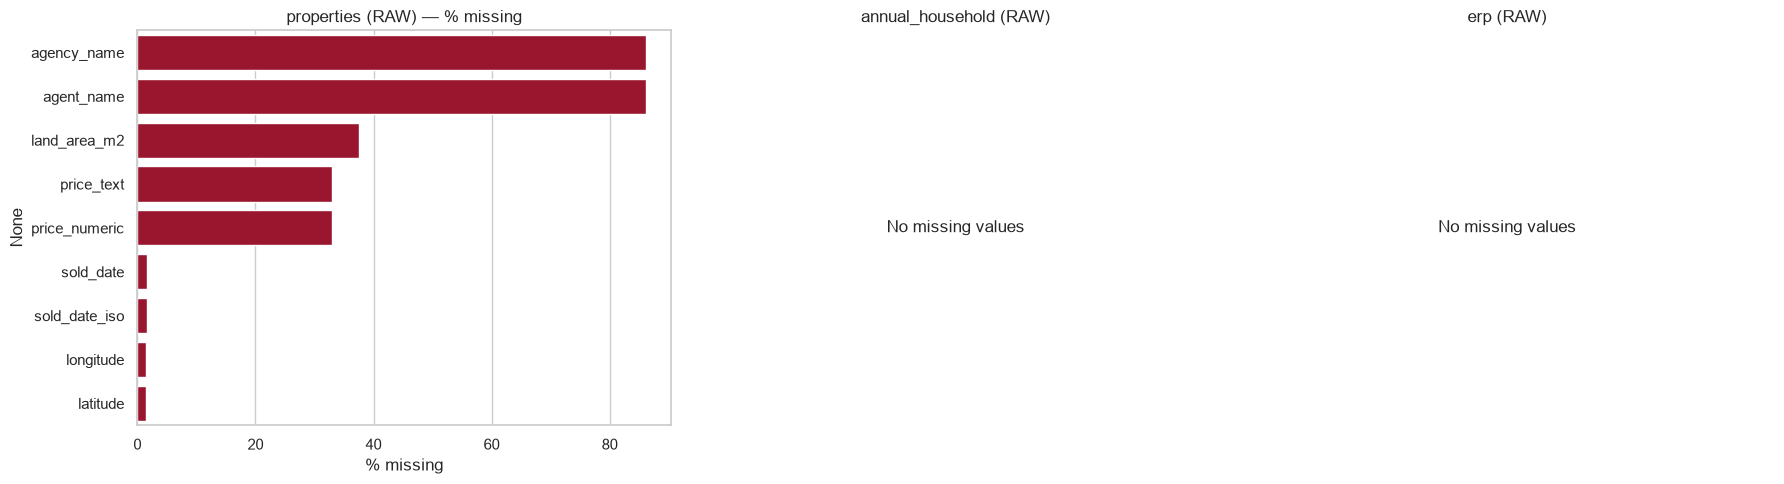


PROPERTIES — RAW
  → INSIGHT [RAW]: suburb looks like a URL slug (e.g. 'anula-nt-0812') — parse into a clean name before joining with census/population data.
  → INSIGHT [RAW]: land_area_m2 looks like text with unit suffixes (e.g. '985m²') — strip non-numeric characters before treating it as a number.
Rows: 15,423 | Unique suburbs: 74 | Sale years: 1920.0–2026.0


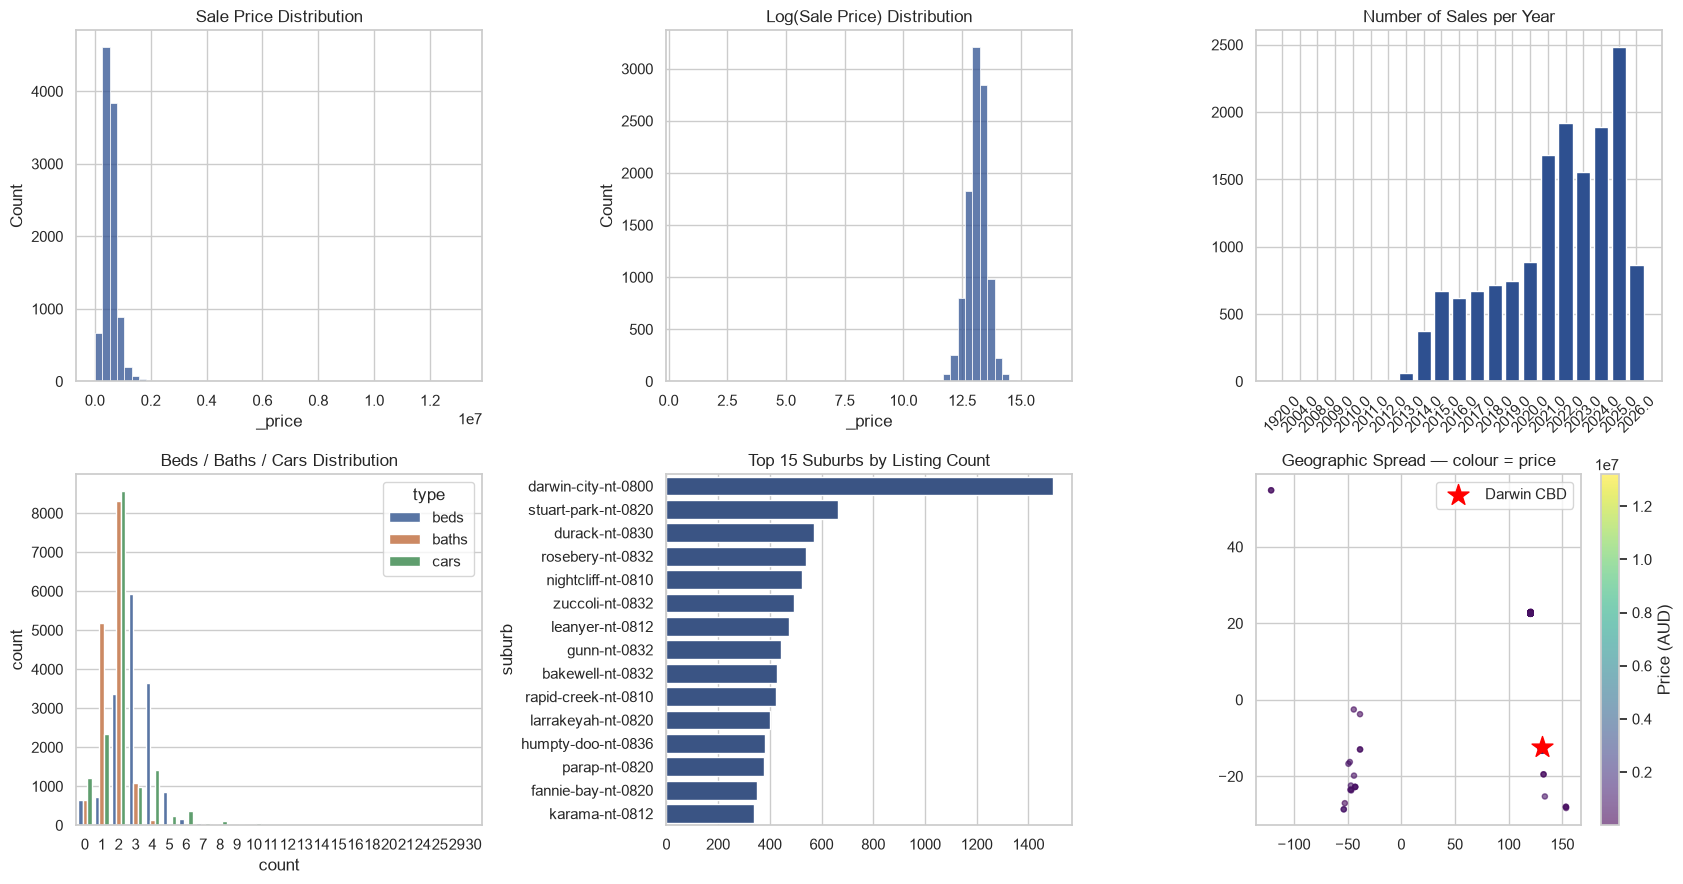

IQR-based price outliers: 337 (3.3%)

ANNUAL HOUSEHOLD INCOME (NT) — RAW
  → INSIGHT [RAW]: Annual household dataset has no parsed 'year' column yet — parse the 'Jun-YYYY' style period labels before using this data. (Which indicators matter can't be determined before that parsing anyway.)

ERP — GREATER DARWIN REGION — RAW
Year coverage: 2006–2026 (21 years)


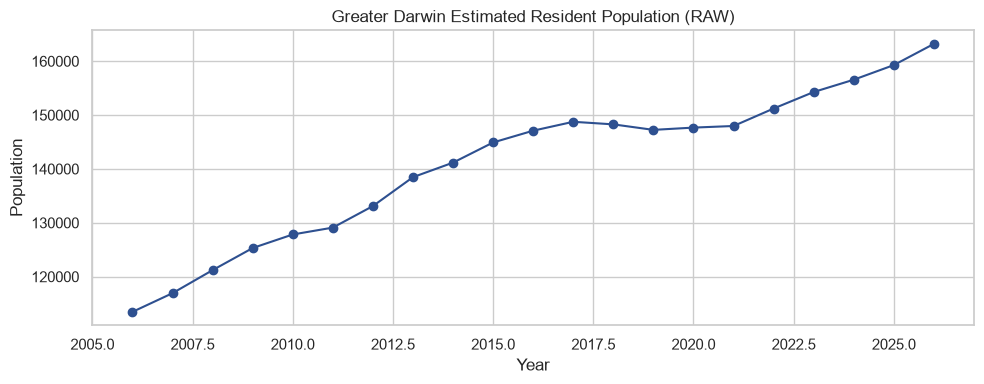


RBA CASH RATE TARGET — RAW
  → INSIGHT [RAW]: RBA cash rate export's real column headers sit on row 2 (row 1 is just a report title), and rows 3-11 are further metadata (Description/Frequency/Units/Source/Publication date/Series ID) -- reparse the header from row 2 and keep only rows whose first column is a valid date.


In [1537]:
household_key_indicators_raw, _ = run_full_eda(
    properties_processed, annual_household_raw, erp_raw, stage="RAW"
)
# household_key_indicators_raw is None here -- 'year' hasn't been parsed on
# annual_household_raw yet, so nothing can be derived at this stage (see docstring above).

eda_cash_rate_profile(cash_rate_raw, stage="RAW")
# Also None at RAW stage here -- the RBA export's real header sits on row 2, not row 1
# (see docstring above), so 'date'/'cash_rate_target' don't exist as columns yet.


## 3. Data Cleaning

### 3.1 Properties Dataset

**Important information from the data (confirmed by the RAW EDA pass above):**

- `suburb` is a **URL slug**, e.g. `"anula-nt-0812"` — not a clean name.
- `land_area_m2` is **text with a unit suffix**, e.g. `"985m²"`.
- `price_undisclosed` is the **string** `"false"`/`"true"`, not `0`/`1`.
- `price_numeric` can be missing even when `price_text` (e.g. `"$540,000"`) is present.

Steps below: parse the suburb slug (into suburb/state/postcode), coerce price/land-area to
numeric, drop/flag undisclosed prices, remove duplicates, and treat outliers using an IQR
filter.

In [1538]:
def parse_suburb_slug(slug):
    """Turns a URL slug like 'coconut-grove-nt-0810' into (suburb, state, postcode)."""
    if pd.isna(slug):
        return pd.Series([np.nan, np.nan, np.nan])
    parts = str(slug).strip().lower().split("-")
    postcode, state = np.nan, np.nan
    if parts and parts[-1].isdigit():
        postcode, parts = parts[-1], parts[:-1]
    if parts and parts[-1].isalpha() and len(parts[-1]) <= 3:
        state, parts = parts[-1].upper(), parts[:-1]
    suburb = " ".join(p.capitalize() for p in parts) if parts else np.nan
    return pd.Series([suburb, state, postcode])


def parse_land_area(value):
    if pd.isna(value):
        return np.nan
    digits = re.sub(r"[^0-9.]", "", str(value))
    return float(digits) if digits else np.nan


def parse_bool_ish(value):
    if isinstance(value, bool):
        return int(value)
    s = str(value).strip().lower()
    if s in ("true", "1", "yes"):
        return 1
    if s in ("false", "0", "no", "nan", ""):
        return 0
    return 0


properties = properties_processed.copy()

properties["suburb_raw"] = properties["suburb"]
properties[["suburb", "state", "postcode"]] = properties["suburb_raw"].apply(parse_suburb_slug)
print("Example suburb parsing:")
print(properties[["suburb_raw", "suburb", "state", "postcode"]].drop_duplicates().head(8).to_string(index=False))

properties["sold_date_iso"] = pd.to_datetime(properties["sold_date_iso"], errors="coerce")

if "land_area_m2" in properties.columns:
    properties["land_area_m2"] = properties["land_area_m2"].apply(parse_land_area)

if "price_undisclosed" in properties.columns:
    properties["price_undisclosed"] = properties["price_undisclosed"].apply(parse_bool_ish)
else:
    properties["price_undisclosed"] = 0

properties["price_numeric"] = pd.to_numeric(properties["price_numeric"], errors="coerce")
if "price_text" in properties.columns:
    needs_fallback = properties["price_numeric"].isna() & properties["price_text"].notna()
    fallback_prices = properties.loc[needs_fallback, "price_text"].astype(str).str.replace(r"[^0-9.]", "", regex=True)
    properties.loc[needs_fallback, "price_numeric"] = pd.to_numeric(fallback_prices, errors="coerce")
    print(f"Recovered {needs_fallback.sum()} prices from price_text via fallback parsing.")

n_before = len(properties)
properties = properties[(properties["price_undisclosed"] == 0) & properties["price_numeric"].notna()].copy()
print(f"Dropped {n_before - len(properties)} rows with undisclosed/missing price ({len(properties)} remain).")

n_before = len(properties)
properties = properties.drop_duplicates(subset=["property_id"])
print(f"Removed {n_before - len(properties)} duplicate records ({len(properties)} remain).")

n_before = len(properties)
properties = properties.dropna(subset=["latitude", "longitude", "sold_date_iso"])
print(f"Dropped {n_before - len(properties)} rows missing coordinates/sale date ({len(properties)} remain).")

# --- IQR outlier filtering without touching the null values ---
def iqr_filter(df, col, k=1.5):
    valid = df[col].notna()
    q1, q3 = df.loc[valid, col].quantile([0.25, 0.75])
    iqr = q3 - q1
    mask = ~valid | df[col].between(q1 - k * iqr, q3 + k * iqr)
    return df[mask], (~mask).sum()

# Narrowed to the years BOTH macro series actually cover: ERP is 2006-2026,
# annual_household is 1990-2025, so the true overlap is 2006-2025. Sales outside that window
# used to get a flat train-set-median population/income fill instead of an observed value --
# a real distortion (e.g. Greater Darwin's 2001-2005 population was meaningfully lower than the
# 2006-2026 median). Dropping them is safer than fabricating macro figures for those rows.
PROPERTIES_YEAR_MIN, PROPERTIES_YEAR_MAX = 2006, 2026
n_before = len(properties)
properties = properties[properties["sold_date_iso"].dt.year.between(PROPERTIES_YEAR_MIN, PROPERTIES_YEAR_MAX)]
print(f"Restricted to sale years {PROPERTIES_YEAR_MIN}\u2013{PROPERTIES_YEAR_MAX} (ERP \u2229 "
      f"annual_household coverage): dropped {n_before - len(properties)} rows outside macro-data "
      f"coverage ({len(properties)} remain).")

n_before = len(properties)
properties, n_out_price = iqr_filter(properties, "price_numeric")
properties, n_out_land = iqr_filter(properties, "land_area_m2")
print(f"IQR outlier filtering removed {n_out_price} price outliers and {n_out_land} land-area outliers ({len(properties)} remain).")

print(f"\nFinal cleaned properties dataset: {len(properties):,} rows.")
properties.to_csv(PROCESSED_DIR / "properties_clean.csv", index=False)

Example suburb parsing:
           suburb_raw        suburb state postcode
        anula-nt-0812         Anula    NT     0812
      bayview-nt-0820       Bayview    NT     0820
coconut-grove-nt-0810 Coconut Grove    NT     0810
  darwin-city-nt-0800   Darwin City    NT     0800
   fannie-bay-nt-0820    Fannie Bay    NT     0820
      jingili-nt-0810       Jingili    NT     0810
       karama-nt-0812        Karama    NT     0812
   larrakeyah-nt-0820    Larrakeyah    NT     0820
Recovered 0 prices from price_text via fallback parsing.
Dropped 5088 rows with undisclosed/missing price (10335 remain).
Removed 0 duplicate records (10335 remain).
Dropped 126 rows missing coordinates/sale date (10209 remain).
Restricted to sale years 2006–2026 (ERP ∩ annual_household coverage): dropped 1 rows outside macro-data coverage (10208 remain).
IQR outlier filtering removed 363 price outliers and 913 land-area outliers (8932 remain).

Final cleaned properties dataset: 8,932 rows.


### 3.2 Annual Household Income Dataset (NT, Time Series)

**Important information from the RAW EDA pass above:**

- The file includes several **metadata rows** at the top (`Unit`, `Series Type`, `Data Type`,
  `Frequency`, `Collection Month`, `Series Start`, `Series End`, `No. Obs`, `Series ID`) before
  the actual annual data begins. You mentioned you'll delete these yourself before upload — the
  cleaning step below also filters for valid `Mon-YYYY` rows defensively, in case a metadata row
  slips through.
- The period column (e.g. `"Jun-1990"`) needs to be parsed into a plain integer `year`.
- Column names have a trailing `" ;"` and inconsistent casing/punctuation — cleaned into
  snake_case for consistency with the rest of the pipeline.
- This dataset is **NT-wide**, not suburb-level — it merges into `properties` on `year` only, no
  suburb key required.

In [1539]:
def clean_column_name(col):
    col = col.strip().rstrip(";").strip()
    col = re.sub(r"[^0-9a-zA-Z]+", "_", col).strip("_").lower()
    return col

annual_household = annual_household_raw.copy()
annual_household = annual_household.rename(columns={annual_household.columns[0]: "period"})

# Defensive filter: keep only rows that look like "Mon-YYYY" (drops any metadata rows)
valid_period = annual_household["period"].astype(str).str.match(r"^[A-Za-z]{3}-\d{4}$")
n_dropped = (~valid_period).sum()
if n_dropped:
    print(f"Dropped {n_dropped} non-data (metadata) row(s): "
          f"{annual_household.loc[~valid_period, 'period'].tolist()}")
annual_household = annual_household[valid_period].copy()

# Parse "Jun-1990" -> 1990 (financial year label treated as the reference year for joining)
annual_household["year"] = pd.to_datetime(annual_household["period"], format="%b-%Y").dt.year
annual_household = annual_household.drop(columns=["period"])

# Clean column names into snake_case; de-duplicate the two distinct "Other secondary income" columns
new_names = {}
seen_other_secondary = 0
for col in annual_household.columns:
    if col == "year":
        continue
    clean = clean_column_name(col)
    if clean == "other_secondary_income":
        seen_other_secondary += 1
        clean = "other_secondary_income_receivable" if seen_other_secondary == 1 else "other_secondary_income_payable"
    new_names[col] = clean
annual_household = annual_household.rename(columns=new_names)

# Coerce every indicator column to numeric
for col in annual_household.columns:
    if col != "year":
        annual_household[col] = pd.to_numeric(annual_household[col], errors="coerce")

print(f"Cleaned annual_household: {annual_household.shape[0]} years x {annual_household.shape[1]} columns")
print(f"Year range: {annual_household['year'].min()}\u2013{annual_household['year'].max()}")
annual_household.to_csv(PROCESSED_DIR / "annual_household_clean.csv", index=False)
annual_household.tail()


Dropped 9 non-data (metadata) row(s): ['Unit', 'Series Type', 'Data Type', 'Frequency', 'Collection Month', 'Series Start', 'Series End', 'No. Obs', 'Series ID']
Cleaned annual_household: 36 years x 28 columns
Year range: 1990–2025


,gross_operating_surplus_dwellings_owned_by_persons,gross_mixed_income,compensation_of_employees,total_property_income_receivable,total_primary_income_receivable,secondary_income_receivable_social_benefits_receivable_workers_compensation,secondary_income_receivable_social_benefits_receivable_social_assistance_benefits,secondary_income_receivable_current_transfers_to_non_profit_institutions,other_secondary_income_receivable,total_secondary_income_receivable,total_gross_income,property_income_payable_interest_dwellings,property_income_payable_interest_consumer_debt,property_income_payable_unincorporated_enterprises,total_property_income_payable,total_primary_income_payable,secondary_income_payable_income_tax,secondary_income_payable_social_contributions_for_workers_compensation,secondary_income_payable_other_current_taxes_on_income_wealth_etc,other_secondary_income_1,total_secondary_income_payable,total_income_payable,gross_disposable_income,final_consumption_expenditure,net_saving_plus_consumption_of_fixed_capital,total_gross_income_per_capita,gross_household_disposable_income_per_capita,year
40,2577,2046,11624,1880,18126,70,1560,211,512,2353,20479,348,76,33,457,457,2035,69,37,588,2729,3186,17293,11263,6030,82635,69780,2021
41,2855,2279,12362,2177,19673,82,1526,261,554,2423,22096,326,67,35,429,429,2175,86,37,647,2945,3374,18722,12142,6580,88206,74738,2022
42,3147,2294,12984,2433,20857,90,1442,311,532,2376,23233,594,77,68,740,740,2486,100,39,691,3316,4055,19178,13319,5859,91006,75121,2023
43,3349,2289,13862,2570,22069,97,1573,321,630,2621,24690,765,95,82,942,942,2759,108,40,720,3626,4568,20122,14237,5886,95307,77673,2024
44,3441,2598,15080,2733,23853,106,1675,295,668,2744,26597,786,99,132,1017,1017,2820,117,46,764,3746,4763,21833,14975,6858,101440,83273,2025


In [1540]:
def project_annual_household_year(annual_household_df, target_year, method="cagr", lookback_years=5):
    """
    ABS hasn't published real annual household income data for `target_year` yet -- the
    2025-26 State Accounts release (which would cover this) isn't due until 18 Nov 2026.
    This projects a `target_year` row from the most recent `lookback_years` of REAL data,
    so 2026 property sales don't get dropped from macro-coverage entirely while we wait.

    method="cagr":   grows each indicator by its own compound annual growth rate over the
                     lookback window (good default -- most of these indicators compound).
    method="linear": fits a straight line per indicator over the lookback window instead
                     (steadier if a series has a lot of year-to-year noise).

    Returns a DataFrame with ONE row for target_year, every indicator estimated, plus an
    `is_projected=True` flag so nothing downstream mistakes it for a real observation.
    """
    df = annual_household_df.sort_values("year")
    recent = df[df["year"] >= df["year"].max() - lookback_years + 1]
    indicator_cols = [c for c in df.columns if c not in ("year", "is_projected")]
    years_ahead = target_year - df["year"].max()

    projected = {"year": target_year, "is_projected": True}

    for col in indicator_cols:
        series = recent[["year", col]].dropna()
        if len(series) < 2:
            projected[col] = df[col].iloc[-1]  # fallback: carry the last known value forward
            continue

        if method == "cagr":
            first_val, last_val = series[col].iloc[0], series[col].iloc[-1]
            n_periods = series["year"].iloc[-1] - series["year"].iloc[0]
            if first_val <= 0 or n_periods == 0:
                projected[col] = last_val
                continue
            cagr = (last_val / first_val) ** (1 / n_periods) - 1
            projected[col] = last_val * (1 + cagr) ** years_ahead

        elif method == "linear":
            coeffs = np.polyfit(series["year"], series[col], deg=1)
            projected[col] = np.polyval(coeffs, target_year)

    return pd.DataFrame([projected])


# --- usage: append a projected 2026 row onto the cleaned annual_household frame ---
annual_household["is_projected"] = False  # mark every real (ABS-published) row as real

projected_2026 = project_annual_household_year(
    annual_household, target_year=2026, method="cagr", lookback_years=5
)
annual_household = pd.concat([annual_household, projected_2026], ignore_index=True).sort_values("year")

note("PROJECTION",
     "ABS's real 2025-26 State Accounts release isn't due until 18 Nov 2026, so the 2026 "
     "annual_household row is a 5-year CAGR projection from 2021-2025, not an observed "
     "figure -- flagged via is_projected=True. Document this as an assumption in the report.")

annual_household.tail(3)

  → INSIGHT [PROJECTION]: ABS's real 2025-26 State Accounts release isn't due until 18 Nov 2026, so the 2026 annual_household row is a 5-year CAGR projection from 2021-2025, not an observed figure -- flagged via is_projected=True. Document this as an assumption in the report.


,gross_operating_surplus_dwellings_owned_by_persons,gross_mixed_income,compensation_of_employees,total_property_income_receivable,total_primary_income_receivable,secondary_income_receivable_social_benefits_receivable_workers_compensation,secondary_income_receivable_social_benefits_receivable_social_assistance_benefits,secondary_income_receivable_current_transfers_to_non_profit_institutions,other_secondary_income_receivable,total_secondary_income_receivable,total_gross_income,property_income_payable_interest_dwellings,property_income_payable_interest_consumer_debt,property_income_payable_unincorporated_enterprises,total_property_income_payable,total_primary_income_payable,secondary_income_payable_income_tax,secondary_income_payable_social_contributions_for_workers_compensation,secondary_income_payable_other_current_taxes_on_income_wealth_etc,other_secondary_income_1,total_secondary_income_payable,total_income_payable,gross_disposable_income,final_consumption_expenditure,net_saving_plus_consumption_of_fixed_capital,total_gross_income_per_capita,gross_household_disposable_income_per_capita,year,is_projected
34,3349.000000,2289.00000,13862.000000,2570.000000,22069.000000,97.000000,1573.000000,321.000000,630.000000,2621.000000,24690.000000,765.000000,95.000000,82.00000,942.000000,942.000000,2759.000000,108.000000,40.000000,720.000000,3626.000000,4568.000000,20122.000000,14237.000000,5886.000000,95307.000000,77673.000000,2024,False
35,3441.000000,2598.00000,15080.000000,2733.000000,23853.000000,106.000000,1675.000000,295.000000,668.000000,2744.000000,26597.000000,786.000000,99.000000,132.00000,1017.000000,1017.000000,2820.000000,117.000000,46.000000,764.000000,3746.000000,4763.000000,21833.000000,14975.000000,6858.000000,101440.000000,83273.000000,2025,False
36,3698.939569,2757.86197,16093.954775,3000.959106,25547.785803,117.586597,1705.050964,320.779722,713.925818,2851.508379,28393.153485,963.570225,105.764664,186.67619,1242.144558,1242.144558,3059.639662,133.511924,48.573216,815.684795,4054.700983,5266.708526,23143.241279,16080.332248,7082.189171,106775.236692,87035.719189,2026,True


### 3.3 ERP Dataset (Greater Darwin Region)
`ERP.csv` stores one row per year (2006–2026) with the Greater Darwin Estimated Resident
Population. The `Number` column is text with thousands-separator commas (e.g. `"1,63,219"`) —
stripped and converted to numeric here. There is no suburb dimension to standardise or reshape;
this is already a tidy year-indexed series, ready to merge on `year` alone.


In [1541]:
erp = erp_raw.copy()
erp = erp.rename(columns={"Year": "year", "Number": "population"})
erp["population"] = pd.to_numeric(erp["population"].astype(str).str.replace(",", "", regex=False), errors="coerce")
erp["year"] = pd.to_numeric(erp["year"], errors="coerce").astype(int)
erp = erp.sort_values("year").reset_index(drop=True)
erp.to_csv(PROCESSED_DIR / "erp_clean.csv", index=False)
erp.head()



,year,population
0,2006,113461
1,2007,116935
2,2008,121210
3,2009,125315
4,2010,127829


### 3.4 RBA Cash Rate Dataset

**Confirmed by the RAW EDA pass above:** the real column headers (`Title`, `Change in Cash Rate
Target`, `New Cash Rate Target`, ...) sit on **row 2** of the RBA export, not row 1 — row 1 is
just a report title, which is what the generic `load_csv()` call in Section 1 picked up as the
header by default. The rows below that are further metadata (`Description`, `Frequency`, `Type`,
`Units`, `Source`, `Publication date`, `Series ID`, plus a couple of blank rows) before the
actual rate-change events start.

Steps below: recover the real header from row 2, keep only rows whose first column parses as a
valid date, and take the **midpoint** of the handful of early (pre-1994) rows where
`New Cash Rate Target` was reported as a range (e.g. `"17.00 to 17.50"`, from when the RBA used a
corridor rather than a single target) rather than a single number. Every Darwin property sale in
this dataset happened well after that changed, but the parsing needs to be safe regardless.


In [1542]:
def parse_rate_value(value):
    """Most rows are a single number; a handful of pre-1994 rows report the target as a range
    (e.g. '17.00 to 17.50') -- those are resolved to their midpoint."""
    if pd.isna(value):
        return np.nan
    s = str(value).strip()
    if " to " in s:
        lo, hi = s.split(" to ")
        return (float(lo) + float(hi)) / 2
    return float(s)


cash_rate = cash_rate_raw.copy()

# Recover the real header from row 2 of the export (row 1 is a report title, already consumed
# as the header by the generic load_csv() call in Section 1).
real_header = cash_rate.iloc[0].tolist()
real_header[0] = "date"
cash_rate.columns = real_header
cash_rate = cash_rate.iloc[1:].reset_index(drop=True)

# Keep only rows whose first column is a genuine 'DD-Mon-YYYY' date -- this drops every
# metadata row (Description/Frequency/Type/Units/Source/Publication date/Series ID/blanks) in
# one pass, the same defensive-filter approach used for annual_household in Section 3.2.
parsed_date = pd.to_datetime(cash_rate["date"], format="%d-%b-%Y", errors="coerce")
n_dropped = int(parsed_date.isna().sum())
cash_rate = cash_rate.loc[parsed_date.notna()].copy()
cash_rate["date"] = parsed_date.loc[parsed_date.notna()]
# Match properties["sold_date_iso"]'s tz-awareness (UTC) so merge_asof's join keys
# are the same dtype -- otherwise it raises a MergeError.
if pd.api.types.is_datetime64_any_dtype(properties["sold_date_iso"]) and \
        properties["sold_date_iso"].dt.tz is not None:
    cash_rate["date"] = cash_rate["date"].dt.tz_localize(properties["sold_date_iso"].dt.tz)
print(f"Dropped {n_dropped} non-data (header/metadata) row(s) from the RBA export.")

cash_rate = cash_rate.rename(columns={"New Cash Rate Target": "cash_rate_target"})
cash_rate["cash_rate_target"] = cash_rate["cash_rate_target"].apply(parse_rate_value)
cash_rate = cash_rate[["date", "cash_rate_target"]].sort_values("date").reset_index(drop=True)

print(f"Cleaned cash_rate: {cash_rate.shape[0]} rate-change events "
      f"({cash_rate['date'].min().date()} to {cash_rate['date'].max().date()})")
cash_rate.to_csv(PROCESSED_DIR / "cash_rate_clean.csv", index=False)
cash_rate.tail()


Dropped 9 non-data (header/metadata) row(s) from the RBA export.
Cleaned cash_rate: 98 rate-change events (1990-01-23 to 2026-05-06)


,date,cash_rate_target
93,2025-05-21 00:00:00+00:00,3.85
94,2025-08-13 00:00:00+00:00,3.60
95,2026-02-04 00:00:00+00:00,3.85
96,2026-03-18 00:00:00+00:00,4.10
97,2026-05-06 00:00:00+00:00,4.35


## 3.5 Run EDA — Pass 2: Data After Cleaning

Same functions, run again on the cleaned data. Compare this against the Pass 1 output above:
the suburb-slug/land-area warnings should be gone, and the annual household dataset should now
show a clean, gap-free 1990–2025 range with real trend lines instead of a "single snapshot"
warning, and the RBA cash rate plot should now render (it returned `None` at RAW stage).


######################################################################
# FULL EDA PASS — STAGE: CLEANED
######################################################################
  → INSIGHT [CLEANED]: 'agency_name' in properties is 80% missing — decide: impute, drop column, or drop rows.
  → INSIGHT [CLEANED]: 'agent_name' in properties is 80% missing — decide: impute, drop column, or drop rows.
  → INSIGHT [CLEANED]: 'land_area_m2' in properties is 41% missing — decide: impute, drop column, or drop rows.


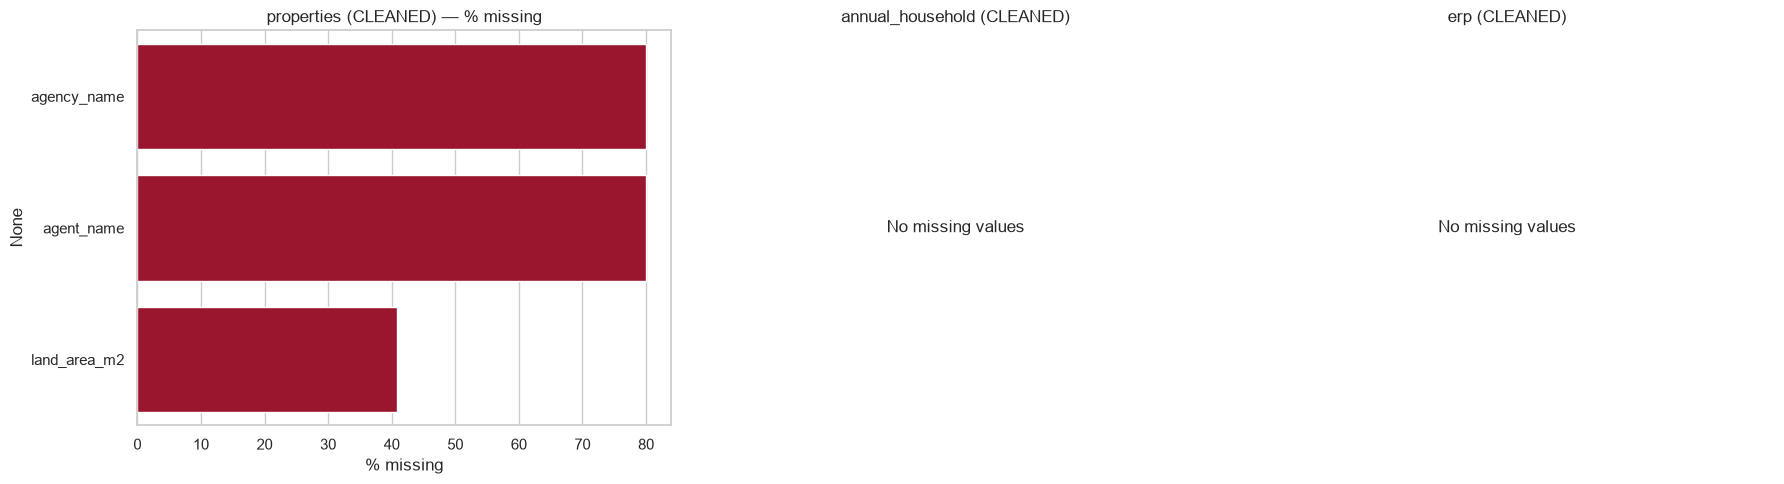


PROPERTIES — CLEANED
Rows: 8,932 | Unique suburbs: 66 | Sale years: 2012–2026


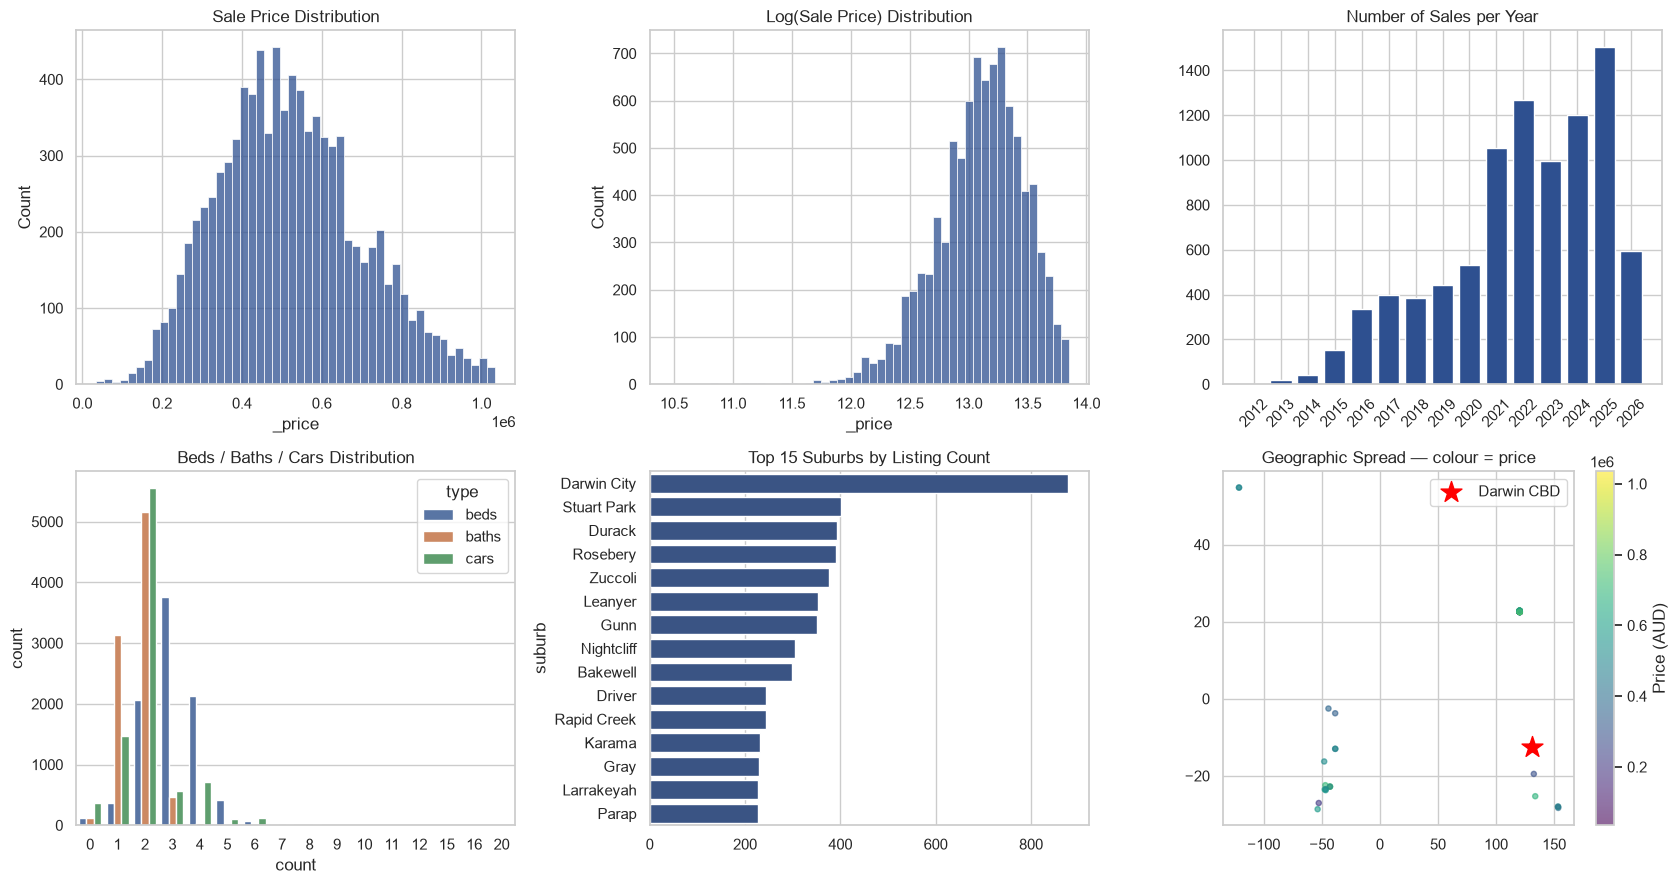

IQR-based price outliers: 58 (0.6%)

ANNUAL HOUSEHOLD INCOME (NT) — CLEANED
Year coverage: 1990–2026 (37 years)


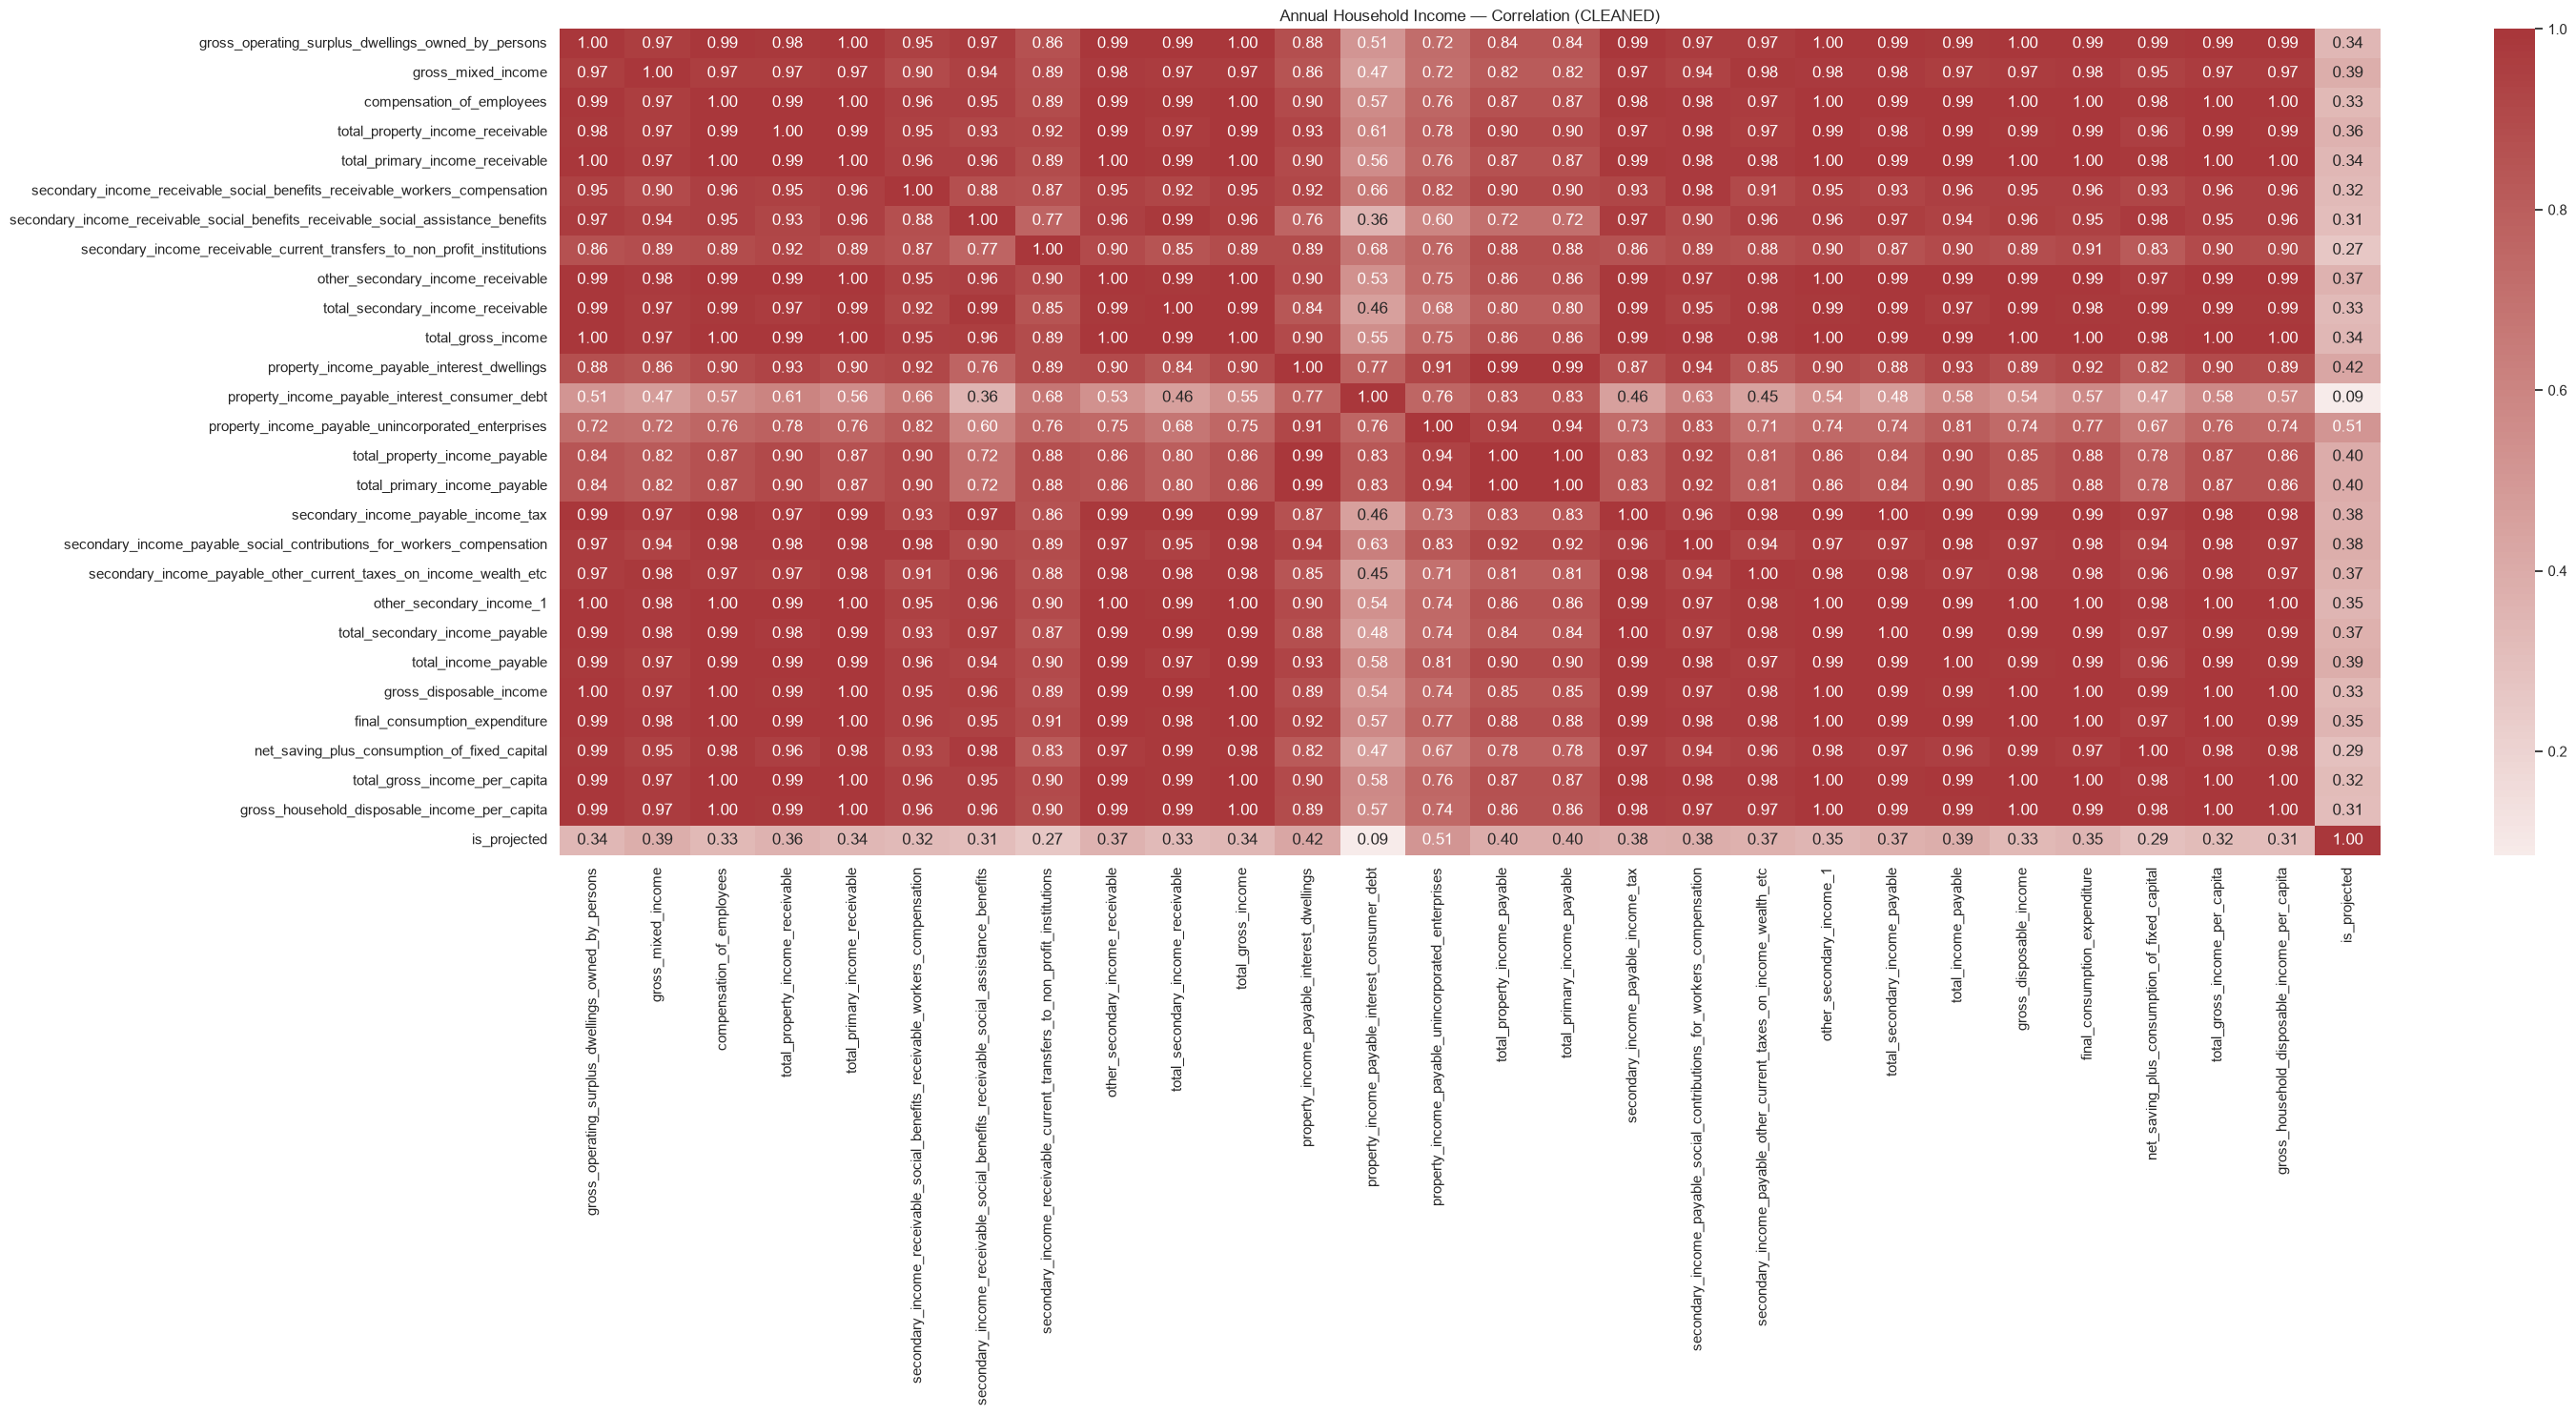

  → INSIGHT [CLEANED]: Indicators ['gross_operating_surplus_dwellings_owned_by_persons', 'gross_mixed_income', 'compensation_of_employees', 'total_property_income_receivable', 'total_primary_income_receivable', 'secondary_income_receivable_social_benefits_receivable_workers_compensation', 'secondary_income_receivable_social_benefits_receivable_social_assistance_benefits', 'other_secondary_income_receivable', 'total_secondary_income_receivable', 'total_gross_income', 'secondary_income_payable_income_tax', 'secondary_income_payable_social_contributions_for_workers_compensation', 'secondary_income_payable_other_current_taxes_on_income_wealth_etc', 'other_secondary_income_1', 'total_secondary_income_payable', 'total_income_payable', 'gross_disposable_income', 'final_consumption_expenditure', 'net_saving_plus_consumption_of_fixed_capital', 'total_gross_income_per_capita', 'gross_household_disposable_income_per_capita'] are highly correlated (>= 0.9) — kept 'total_gross_income' as the repres

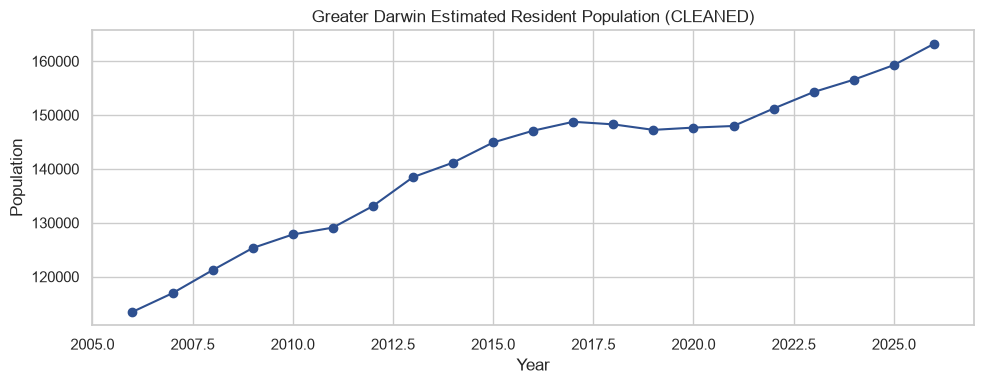


Derived household_features (correlation-clustered, CLEANED stage):
['total_gross_income', 'secondary_income_receivable_current_transfers_to_non_profit_institutions', 'total_property_income_payable', 'property_income_payable_interest_consumer_debt', 'is_projected']

RBA CASH RATE TARGET — CLEANED
Rate-change events: 98 | Date range: 1990-01-23 to 2026-05-06


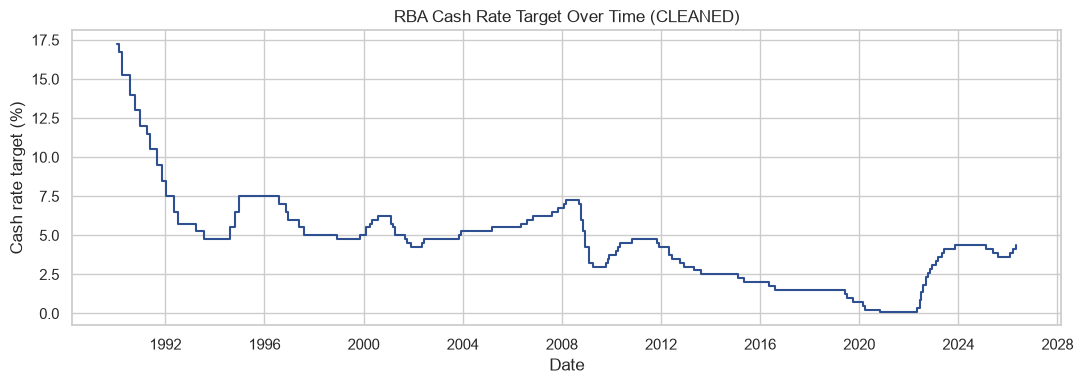

  → INSIGHT [CLEANED]: Year(s) with a single RBA move of >=1.00 percentage point: [1990, 1991, 1992, 1994, 2008, 2009] — these are the sharpest affordability shocks in the series, worth checking against the property test-set years for regime-shift effects.


,date,cash_rate_target,_step_change
0,1990-01-23 00:00:00+00:00,17.25,NaN
1,1990-02-15 00:00:00+00:00,16.75,-0.50
2,1990-04-04 00:00:00+00:00,15.25,-1.50
3,1990-08-02 00:00:00+00:00,14.00,-1.25
4,1990-10-15 00:00:00+00:00,13.00,-1.00
...,...,...,...
93,2025-05-21 00:00:00+00:00,3.85,-0.25
94,2025-08-13 00:00:00+00:00,3.60,-0.25
95,2026-02-04 00:00:00+00:00,3.85,0.25
96,2026-03-18 00:00:00+00:00,4.10,0.25


In [1543]:
household_key_indicators, _ = run_full_eda(properties, annual_household, erp, stage="CLEANED")
print("\nDerived household_features (correlation-clustered, CLEANED stage):")
print(household_key_indicators)

eda_cash_rate_profile(cash_rate, stage="CLEANED")


## 4. Feature Engineering

### 4.1 Distance from Darwin CBD

In [1544]:
def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    return 2 * R * np.arcsin(np.sqrt(a))

properties["distance_from_cbd_km"] = haversine_km(
    properties["latitude"], properties["longitude"], DARWIN_CBD_LAT, DARWIN_CBD_LON
)


### 4.2 Exact year from the date

In [1545]:
properties["sale_year"] = properties["sold_date_iso"].dt.year
properties["sale_month"] = properties["sold_date_iso"].dt.month

## 5. Merging Datasets

`erp` and `annual_household` merge on **`year` alone** — no suburb key, no fuzzy/composite
matching. `erp` is the Greater Darwin-wide population estimate, and since every property in
`properties` is located within Greater Darwin, every sale gets the correct population figure for
its sale year regardless of which suburb it's in. Same logic as `annual_household` (NT-wide
economic indicators): one value per year, joined straight onto every property sold that year.

`cash_rate` is different: it's an **event-based** series (Section 5.1), so it merges on the
exact **sale date** via a point-in-time (as-of) join, not on `year`.


In [1546]:
# --- merge ERP (year only -- Greater Darwin-wide, no suburb key needed since every
# property in `properties` is located within Greater Darwin) ---
merged = properties.merge(
    erp.rename(columns={"year": "erp_year", "population": "erp_population"}),
    left_on="sale_year", right_on="erp_year", how="left"
)

# --- merge annual_household (year only -- NT-wide, no suburb key) ---
merged = merged.merge(
    annual_household, left_on="sale_year", right_on="year", how="left", suffixes=("", "_nt")
)

print(f"ERP population match rate: {merged['erp_population'].notna().mean()*100:.1f}% "
      f"(should be ~100% — continuous year-only join, every sale is within Greater Darwin)")
print(f"Annual household match rate: {merged['total_gross_income'].notna().mean()*100:.1f}% "
      f"(should be ~100% since it's a continuous year-only join)")


ERP population match rate: 100.0% (should be ~100% — continuous year-only join, every sale is within Greater Darwin)
Annual household match rate: 100.0% (should be ~100% since it's a continuous year-only join)


### 5.1 Merge RBA Cash Rate (Point-in-Time As-Of Join)

Unlike ERP/annual-household, this doesn't merge on `year` — it's a point-in-time join: each
property sale gets the RBA cash rate target that was **actually in effect on its sale date**
(the most recent rate change on or before that date), via `pd.merge_asof` on the sorted date
columns. Two features come out of this:

- **`cash_rate_target`** — the level of the cash rate at the time of sale.
- **`cash_rate_change_12m`** — how much the rate moved in the 12 months *before* the sale, i.e.
  the pace of recent hikes/cuts. This tracks buyer affordability stress more directly than the
  level alone, especially through the sharp 2022–2023 hiking cycle flagged by the CLEANED-stage
  EDA pass above.

Both are exogenous, publicly-known-at-the-time data (like ERP/annual-household), so there's no
leakage risk in computing them before the temporal train/test split in Section 6 — nothing here
is estimated *from* the property/price data itself, only from the sale date, which is already
fixed and known.


In [1547]:
merged = merged.sort_values("sold_date_iso")

# --- cash rate AT the sale date (most recent RBA change on or before that date) ---
merged = pd.merge_asof(
    merged, cash_rate, left_on="sold_date_iso", right_on="date", direction="backward"
).drop(columns=["date"])

# --- cash rate 12 months BEFORE the sale date, to derive the recent pace of change ---
cash_rate_12m_ago = cash_rate.rename(
    columns={"date": "date_12m_ago", "cash_rate_target": "cash_rate_target_12m_ago"}
).sort_values("date_12m_ago")

merged["_date_12m_ago"] = merged["sold_date_iso"] - pd.DateOffset(months=12)
merged = merged.sort_values("_date_12m_ago")
merged = pd.merge_asof(
    merged, cash_rate_12m_ago, left_on="_date_12m_ago", right_on="date_12m_ago",
    direction="backward"
).drop(columns=["date_12m_ago", "_date_12m_ago"])

merged["cash_rate_change_12m"] = merged["cash_rate_target"] - merged["cash_rate_target_12m_ago"]
merged = merged.drop(columns=["cash_rate_target_12m_ago"])
merged = merged.sort_values("sold_date_iso").reset_index(drop=True)

print(f"Cash rate match rate: {merged['cash_rate_target'].notna().mean()*100:.1f}% "
      f"(should be ~100% -- the RBA series starts in 1990, well before any property sale here)")

merged.to_csv(PROCESSED_DIR / "merged_raw.csv", index=False)
print(f"Merged shape: {merged.shape}")


Cash rate match rate: 100.0% (should be ~100% -- the RBA series starts in 1990, well before any property sale here)
Merged shape: (8932, 57)


### 5.2 Year-Coverage Check (replaces the old `years_since_census` feature)

Because `annual_household` is a genuine multi-year series rather than a single snapshot, there
is no systematic "future data" leakage to correct for here — every sale year should find a
matching row directly. This just confirms that's actually true rather than assuming it.

In [1548]:
unmatched_years = merged.loc[merged["total_gross_income"].isna(), "sale_year"].unique()
if len(unmatched_years):
    note("POST-MERGE", f"Sale year(s) with no annual_household match: {unmatched_years} ")
else:
    print("Every sale year matched the annual household series exactly \u2014 no gap-filling needed.")


Every sale year matched the annual household series exactly — no gap-filling needed.


### 5.3 Build Model-Ready Frame (Row Filtering Only — No Imputation Yet)

Only rows with a known `price_numeric` (the target) are dropped here — a row with an unknown
target can't be used for training or evaluation either way, so that's not a leakage risk.
Everything else is left untouched: missing feature values stay as `NaN` for now.

**Why imputation is deferred:** filling a `NaN` with, say, `land_area_m2.median()` computed over
the *entire* dataset means every training-set property's imputed value is influenced — even
slightly — by test-set properties the model shouldn't have any information about at
prediction time. That's leakage. The fix is standard practice: split first (Section 6), then fit
any imputation statistic on the **training set only**, and apply that same fitted statistic to
the test set (Section 7).

`price_per_sqm` is also deliberately left out of `numeric_candidates` here — see the code
cell for why.

In [1549]:
model_df = merged.dropna(subset=["price_numeric"]).copy()

# household_features now comes directly from the correlation-clustering pass in
# eda_annual_household_profile (run via run_full_eda at the CLEANED stage above) instead of a
# hardcoded list disconnected from any correlation check -- see `household_key_indicators`.
household_features = [c for c in (household_key_indicators or []) if c in model_df.columns]
if not household_features:
    raise RuntimeError(
        "household_key_indicators is empty/None -- check that the CLEANED-stage run_full_eda "
        "call ran successfully and that 'year' was parsed on annual_household before that call."
    )

# "price_per_sqm" is NOT a model feature: it's literally price_numeric / land_area_m2, i.e. the
# TARGET divided by another feature. Feeding that to the model as a predictor would let it
# trivially reconstruct price_numeric (price = price_per_sqm * land_area_m2) -- that's target
# leakage, a more severe problem than the imputation-timing issue this section fixes. It's
# computed later (Section 8) purely for a descriptive summary, and is never added here.
#
# sale_year / sale_month: previously computed (Section 4.2) but never added here, so the model
# only saw a "time" signal indirectly through the macro indicators. Decision: for a forecasting
# problem it's better to let the model see the raw trend directly rather than relying on macro
# covariates to carry all of the time signal, so both are included below.
#
# latitude / longitude: previously dropped after deriving distance_from_cbd_km. Kept here
# alongside that derived feature so RF/XGBoost can pick up directional/coastal patterns that a
# single radial distance collapses away (Linear Regression will typically find them close to
# uninformative on their own, so this costs it little).
#
# cash_rate_target / cash_rate_change_12m: from the new RBA cash rate merge (Section 5.1) --
# the level of the cash rate at sale time, and how much it moved in the preceding 12 months.
# Both are exogenous and known at the time of each sale, so including them carries no
# leakage risk (same reasoning as erp_population/household_features above).
numeric_candidates = [
    "beds", "baths", "cars", "land_area_m2", "distance_from_cbd_km",
    "latitude", "longitude", "erp_population", "sale_year", "sale_month",
    "cash_rate_target", "cash_rate_change_12m",
] + household_features
numeric_candidates = [c for c in numeric_candidates if c in model_df.columns]

for col in numeric_candidates:
    model_df[col] = pd.to_numeric(model_df[col], errors="coerce")

missing_summary = model_df[numeric_candidates].isna().sum()
missing_summary = missing_summary[missing_summary > 0]
print("Numeric features retained for modelling:", numeric_candidates)
print(f"Rows with a known price: {model_df.shape[0]:,} | columns: {model_df.shape[1]}")
if len(missing_summary):
    print("\nMissing values remain in these features (left as-is on purpose — imputed AFTER "
          "the temporal split in Section 7, using train-only statistics):")
    print(missing_summary)
else:
    print("\nNo missing values in the retained numeric features.")

Numeric features retained for modelling: ['beds', 'baths', 'cars', 'land_area_m2', 'distance_from_cbd_km', 'latitude', 'longitude', 'erp_population', 'sale_year', 'sale_month', 'cash_rate_target', 'cash_rate_change_12m', 'total_gross_income', 'secondary_income_receivable_current_transfers_to_non_profit_institutions', 'total_property_income_payable', 'property_income_payable_interest_consumer_debt', 'is_projected']
Rows with a known price: 8,932 | columns: 57

Missing values remain in these features (left as-is on purpose — imputed AFTER the temporal split in Section 7, using train-only statistics):
land_area_m2    3649
dtype: int64


## 6. Temporal Train/Test Split

This is a **forecasting** problem, so the split is by time (train on earlier sales, test on the
most recent) rather than random — a random split would let the model "see" pricing patterns
from sales that happened after the ones it's being tested on, which is a form of leakage the
Week 2/3 lectures explicitly warn against.

The split happens here — straight after row filtering, and **before** imputation, scaling,
or any other statistic gets computed from the data. That ordering is what Section 7 depends on:
nothing derived from `test_df` is ever allowed to influence `train_df`, or vice versa.

In [1550]:
model_df = model_df.sort_values("sold_date_iso").reset_index(drop=True)
cutoff = model_df["sold_date_iso"].quantile(0.8)
train_df = model_df[model_df["sold_date_iso"] <= cutoff].copy()
test_df = model_df[model_df["sold_date_iso"] > cutoff].copy()

print(f"Temporal cutoff: {cutoff.date()}")
print(f"Train: {len(train_df):,} rows ({train_df['sold_date_iso'].min().date()} to {train_df['sold_date_iso'].max().date()})")
print(f"Test:  {len(test_df):,} rows ({test_df['sold_date_iso'].min().date()} to {test_df['sold_date_iso'].max().date()})")


Temporal cutoff: 2025-03-27
Train: 7,150 rows (2012-08-14 to 2025-03-27)
Test:  1,782 rows (2025-03-28 to 2026-08-11)


## 7. Imputation (Train-Only Statistics, Applied to Both Splits)

Any statistic used to fill a missing value — a median, a group-median, a k-NN lookup, anything —
is **fit on `train_df` only**, then applied unchanged to both `train_df` and `test_df`. This is
the same fit/transform discipline `StandardScaler`/`OneHotEncoder` follow in the preprocessing
pipeline in Section 10.

`land_area_m2` is deliberately **not** filled here — see Section 7.1, where it gets a
neighbour-based (k-NN) fill using location + beds instead of a single grouped median. Every
other numeric feature gets `train_df`'s own median.


In [1551]:
def fit_impute_stats(df, numeric_cols):
    """Learns imputation statistics from df -- this MUST be the TRAINING split only.
    land_area_m2 is excluded here on purpose -- Section 7.1 fills it with a k-NN model
    (location + beds) instead of a single grouped median; see that section for why."""
    stats = {}
    for col in numeric_cols:
        if col == "land_area_m2":
            continue
        stats[col] = {"global": df[col].median()}
    return stats


def apply_impute_stats(df, numeric_cols, stats):
    """Fills missing values using PRE-FITTED statistics -- never recomputes from df itself."""
    df = df.copy()
    for col in numeric_cols:
        if col == "land_area_m2" or col not in df.columns or df[col].isna().sum() == 0:
            continue
        df[col] = df[col].fillna(stats[col]["global"])
    return df


impute_stats = fit_impute_stats(train_df, numeric_candidates)          # fit on TRAIN ONLY
train_df = apply_impute_stats(train_df, numeric_candidates, impute_stats)
test_df = apply_impute_stats(test_df, numeric_candidates, impute_stats)  # same stats, no re-fit

for name, d in [("train", train_df), ("test", test_df)]:
    remaining_cols = [c for c in numeric_candidates if c != "land_area_m2"]
    remaining = int(d[remaining_cols].isna().sum().sum())
    status = "clean" if remaining == 0 else f"{remaining} missing value(s) still remain"
    print(f"{name}_df after imputation (excl. land_area_m2, handled in Section 7.1): {status}")


train_df after imputation (excl. land_area_m2, handled in Section 7.1): clean
test_df after imputation (excl. land_area_m2, handled in Section 7.1): clean


## 7.1 land_area_m2 Imputation — k-NN on Location + Beds (train-only fit)

The original approach filled `land_area_m2` with a **beds-grouped median** — properties with
more bedrooms tend to sit on more land, so a beds-specific number beats one global median. But
it still collapses every property with, say, 3 beds into a single fill value regardless of
*where* it is — a 3-bed block in the CBD and a 3-bed rural-residential block get the same fill,
which is a lot of avoidable noise for a location-driven price signal.

Instead, `land_area_m2` is filled with a **k-NN model over `beds`, `latitude`, `longitude`**
(scaled first, so degrees of longitude don't get outweighed by a raw bedroom count): for each
row missing `land_area_m2`, it looks up the `k` nearest properties (by scaled beds/location) in
the training set and fills with their **distance-weighted mean land area**. The k-NN itself is
`fit` on `train_df` only (same discipline as every other imputation step) and only ever
`transform`s `test_df`, never refit on it. Any row still unfillable (e.g. missing beds *and*
missing coordinates) falls back to the training-set global median, exactly as before.


In [1552]:
from sklearn.impute import KNNImputer

LAND_AREA_PREDICTORS = [c for c in ["beds", "latitude", "longitude"] if c in train_df.columns]
LAND_AREA_KNN_K = 7


def fit_land_area_imputer(df, predictors=LAND_AREA_PREDICTORS, k=LAND_AREA_KNN_K):
    """Fits a k-NN-based imputer for land_area_m2 using beds/lat/lon as predictors --
    this MUST be the TRAINING split only. Predictors are standardised first so KNN distance
    isn't dominated by whichever column happens to have the largest raw scale."""
    scaler = StandardScaler().fit(df[predictors])
    scaled_predictors = scaler.transform(df[predictors])
    combined = np.column_stack([scaled_predictors, df["land_area_m2"].values])
    imputer = KNNImputer(n_neighbors=k, weights="distance")
    imputer.fit(combined)
    return {
        "scaler": scaler, "imputer": imputer, "predictors": predictors,
        "fallback_median": df["land_area_m2"].median(),
    }


def apply_land_area_imputer(df, stats):
    """Fills land_area_m2 using the PRE-FITTED k-NN imputer -- never re-fit on df itself."""
    df = df.copy()
    scaled_predictors = stats["scaler"].transform(df[stats["predictors"]])
    combined = np.column_stack([scaled_predictors, df["land_area_m2"].values])
    filled = stats["imputer"].transform(combined)[:, -1]
    df["land_area_m2"] = filled
    df["land_area_m2"] = df["land_area_m2"].fillna(stats["fallback_median"])  # last-resort only
    return df


land_area_stats = fit_land_area_imputer(train_df)            # fit on TRAIN ONLY
train_df = apply_land_area_imputer(train_df, land_area_stats)
test_df = apply_land_area_imputer(test_df, land_area_stats)   # same fitted k-NN, no re-fit

for name, d in [("train", train_df), ("test", test_df)]:
    remaining = int(d["land_area_m2"].isna().sum())
    status = "clean" if remaining == 0 else f"{remaining} missing value(s) still remain"
    print(f"{name}_df land_area_m2 after k-NN imputation: {status}")

model_df = pd.concat([train_df, test_df]).sort_values("sold_date_iso").reset_index(drop=True)


train_df land_area_m2 after k-NN imputation: clean
test_df land_area_m2 after k-NN imputation: clean


## 7.2 Suburb Bucketing — Rare Suburbs → "Other" (train-only threshold)

`suburb` goes straight into `OneHotEncoder` today. If there's a long tail of suburbs with only a
handful of training sales, each gets its own one-hot column estimated from very few rows -- that
mostly hurts Linear Regression's stability (tree models split around it more gracefully). The fix
uses the same discipline as imputation above: the "which suburbs count as common" threshold is
learned from `train_df` only, then applied unchanged to `test_df` (and `model_df`, for
consistent downstream reporting) -- so no test-set suburb-frequency information leaks into the
training pipeline.

In [1553]:
SUBURB_MIN_COUNT = 10  # suburbs with fewer than this many TRAINING sales get bucketed

suburb_counts = train_df["suburb"].value_counts()
common_suburbs = set(suburb_counts[suburb_counts >= SUBURB_MIN_COUNT].index)

def bucket_suburb(s):
    return s if s in common_suburbs else "Other"

train_df["suburb"] = train_df["suburb"].apply(bucket_suburb)
test_df["suburb"] = test_df["suburb"].apply(bucket_suburb)
model_df["suburb"] = model_df["suburb"].apply(bucket_suburb)

n_bucketed_train = int((train_df["suburb"] == "Other").sum())
n_bucketed_test = int((test_df["suburb"] == "Other").sum())
print(f"Suburb cardinality before bucketing: {len(suburb_counts)} distinct suburbs in train_df")
print(f"Kept {len(common_suburbs)} suburbs with >= {SUBURB_MIN_COUNT} training sales; "
      f"bucketed the rest into 'Other' ({n_bucketed_train} train rows, {n_bucketed_test} test rows).")

Suburb cardinality before bucketing: 66 distinct suburbs in train_df
Kept 49 suburbs with >= 10 training sales; bucketed the rest into 'Other' (73 train rows, 7 test rows).


## 7.3 Suburb Target Encoding — Recency-Weighted, Smoothed Mean Price by Suburb (train-only fit)

`suburb` going into `OneHotEncoder` treats every suburb as equally uninformative until the model
has seen enough rows to split on it, and Section 7.2 collapses low-count suburbs into `"Other"`
altogether -- which helps Linear Regression's stability but throws away real location signal that
Random Forest/XGBoost could otherwise use directly, since they handle high-cardinality
categoricals fine on their own.

This adds a **numeric** feature, `suburb_target_enc`: each suburb's **recency-weighted, smoothed
mean `price_numeric`**, computed on `train_df` only and then mapped onto `train_df`/`test_df`
unchanged (same fit/transform discipline as every other imputation/encoding step above).

**Why recency-weighted, not a flat mean:** the original version averaged every training sale for
a suburb equally, whether it sold in 2006 or 2022. That's a problem for a market that moved as
much as Darwin's did over that window -- the residual-by-year diagnostic in Section 11.1 showed
the model's error blowing out specifically in 2024/2025, right after the sharp 2022-2023 rate-hike
cycle. A suburb's *relative* standing in the market can shift during a period like that, and a
single 16-year average has no way to reflect where a suburb sits *now* versus where it sat on
average across the whole history. Concretely: each training sale is weighted by
`0.5 ** (years_before_cutoff / SUBURB_ENCODING_HALF_LIFE_YEARS)`, so a sale half a decay-window old
counts half as much as a sale today. `years_before_cutoff` is measured from the training set's own
most recent sale date (fixed at fit time), not from "today" -- so the same weighting logic applies
consistently whether this is run now or six months from now.

Smoothing still pulls low-weight (thin-history) suburbs toward the global mean, exactly as before,
except both the suburb mean and the global mean are now computed as recency-weighted averages, and
the "how much training history do we actually have" count is replaced by the suburb's **total
decay weight** (its effective sample size) rather than its raw row count -- a suburb with 50 old
sales and almost no recent ones now gets treated similarly to a genuinely thin-history suburb,
which is the correct behaviour here.

`smoothed_mean = (weight_sum * suburb_weighted_mean + m * global_weighted_mean) / (weight_sum + m)`

This is built from `suburb_raw` -- the original, un-bucketed suburb identifier saved back in
Section 3.1 -- specifically *because* it isn't touched by Section 7.2's `"Other"` bucketing, so it
can still carry fine-grained location signal that the one-hot branch deliberately coarsens.
Suburbs never seen in training fall back to the training-set global weighted mean. The one-hot
`suburb` column from Section 7.2 is kept as well -- the two features capture the location signal
differently, so there's no need to choose one over the other.


In [1554]:
SUBURB_ENCODING_SMOOTHING = 10       # weight, in "pseudo-sales", given to the global mean
SUBURB_ENCODING_HALF_LIFE_YEARS = 3  # a sale this many years before the training cutoff counts
                                       # for half as much as a sale made on the cutoff date itself


def fit_suburb_target_encoding(df, target_col="price_numeric", date_col="sold_date_iso",
                                m=SUBURB_ENCODING_SMOOTHING,
                                half_life_years=SUBURB_ENCODING_HALF_LIFE_YEARS):
    """Learns a recency-weighted, smoothed mean-price-per-suburb map from df -- this MUST be the
    TRAINING split only, and uses the ORIGINAL 'suburb_raw' column (before Section 7.2's 'Other'
    bucketing) so it isn't undone by -- or duplicated with -- that separate one-hot-focused
    decision.

    Recency weighting: each row's weight is 0.5 ** (years_before_cutoff / half_life_years), where
    years_before_cutoff is measured from THIS training set's own most recent sale date (the
    "cutoff"), fixed once at fit time. A sale from `half_life_years` before the cutoff contributes
    half as much to its suburb's mean as a sale made on the cutoff date itself -- so a suburb's
    encoded value reflects where it sits NOW, not a flat 16-year average that a regime shift (like
    the 2022-2023 rate-hike cycle) can quietly make stale.

    Smoothing still pulls thin-history suburbs toward the (also recency-weighted) global mean,
    exactly as before -- except the "how much do we trust this suburb's own mean" count is now the
    suburb's total decay weight (its effective sample size), not its raw row count. A suburb with
    many OLD sales and few recent ones now correctly gets treated as thin-history, since old sales
    barely contribute weight.
    """
    cutoff = df[date_col].max()
    years_before_cutoff = (cutoff - df[date_col]).dt.days / 365.25
    weight = 0.5 ** (years_before_cutoff / half_life_years)

    d = df[["suburb_raw", target_col]].copy()
    d["_weight"] = weight
    d["_weighted_target"] = d[target_col] * d["_weight"]

    global_mean = d["_weighted_target"].sum() / d["_weight"].sum()

    grouped = d.groupby("suburb_raw").agg(
        weight_sum=("_weight", "sum"),
        weighted_sum=("_weighted_target", "sum"),
    )
    grouped["suburb_mean"] = grouped["weighted_sum"] / grouped["weight_sum"]
    smoothed = (
        (grouped["weight_sum"] * grouped["suburb_mean"] + m * global_mean)
        / (grouped["weight_sum"] + m)
    )
    return {"map": smoothed, "global_mean": global_mean, "cutoff": cutoff,
            "half_life_years": half_life_years}


def apply_suburb_target_encoding(df, stats):
    """Maps PRE-FITTED recency-weighted smoothed suburb means onto df -- never recomputed from df
    itself. Suburbs absent from the training map (unseen in training) fall back to the training
    global weighted mean."""
    df = df.copy()
    df["suburb_target_enc"] = df["suburb_raw"].map(stats["map"]).fillna(stats["global_mean"])
    return df


suburb_encoding_stats = fit_suburb_target_encoding(train_df)             # fit on TRAIN ONLY
train_df = apply_suburb_target_encoding(train_df, suburb_encoding_stats)
test_df = apply_suburb_target_encoding(test_df, suburb_encoding_stats)    # same map, no re-fit
model_df = apply_suburb_target_encoding(model_df, suburb_encoding_stats)  # for consistent reporting

if "suburb_target_enc" not in numeric_candidates:
    numeric_candidates.append("suburb_target_enc")

n_unseen_test = int((~test_df["suburb_raw"].isin(suburb_encoding_stats["map"].index)).sum())
print(f"Suburb target encoding fit on {len(suburb_encoding_stats['map'])} training suburbs "
      f"(smoothing m={SUBURB_ENCODING_SMOOTHING}, recency half-life="
      f"{SUBURB_ENCODING_HALF_LIFE_YEARS}y, cutoff={suburb_encoding_stats['cutoff'].date()}); "
      f"{n_unseen_test} test row(s) fell back to the training global mean (suburb unseen in "
      f"training).")


Suburb target encoding fit on 66 training suburbs (smoothing m=10, recency half-life=3y, cutoff=2025-03-27); 0 test row(s) fell back to the training global mean (suburb unseen in training).


## 8. Feature Engineering Post-Imputation

`price_per_sqm` is computed here, now that `land_area_m2` is fully imputed — but purely as a
**descriptive** figure for the report. As flagged in Section 5.2, it's never added to
`numeric_candidates`: dividing the target by area and feeding that back in as a predictor would
leak the target itself into the model.

In [1555]:
train_df["price_per_sqm"] = train_df["price_numeric"] / train_df["land_area_m2"]
test_df["price_per_sqm"] = test_df["price_numeric"] / test_df["land_area_m2"]
model_df["price_per_sqm"] = model_df["price_numeric"] / model_df["land_area_m2"]

model_df.to_csv(MODEL_READY_DIR / "model_ready.csv", index=False)
model_df[["distance_from_cbd_km", "price_per_sqm", "sale_year", "sale_month"]].describe().T


,count,mean,std,min,25%,50%,75%,max
distance_from_cbd_km,8932.0,69.923819,759.658498,0.013135,5.047482,10.906102,15.697521,18262.529709
price_per_sqm,8932.0,1689.765790,8600.553473,35.971223,706.413246,1038.492378,2000.000000,430000.000000
sale_year,8932.0,2021.962382,2.923642,2012.000000,2020.000000,2022.000000,2024.000000,2026.000000
sale_month,8932.0,6.649687,3.333359,1.000000,4.000000,7.000000,10.000000,12.000000


## 9. Run EDA — Pass 3: Post-Merge (Correlation With Target)

With the target variable (`price_numeric`) now sitting alongside every engineered/merged
feature, this is the point where EDA can actually tell you **which features are worth keeping**.
Run on **`train_df` only** — the same reasoning as the imputation split above: letting
feature-selection decisions be informed by patterns only visible in the test set is a subtler
form of leakage, even though no number gets copied anywhere. Features with near-zero correlation
are candidates to drop or transform; features with strong correlation justify the modelling
choices in Section 11.

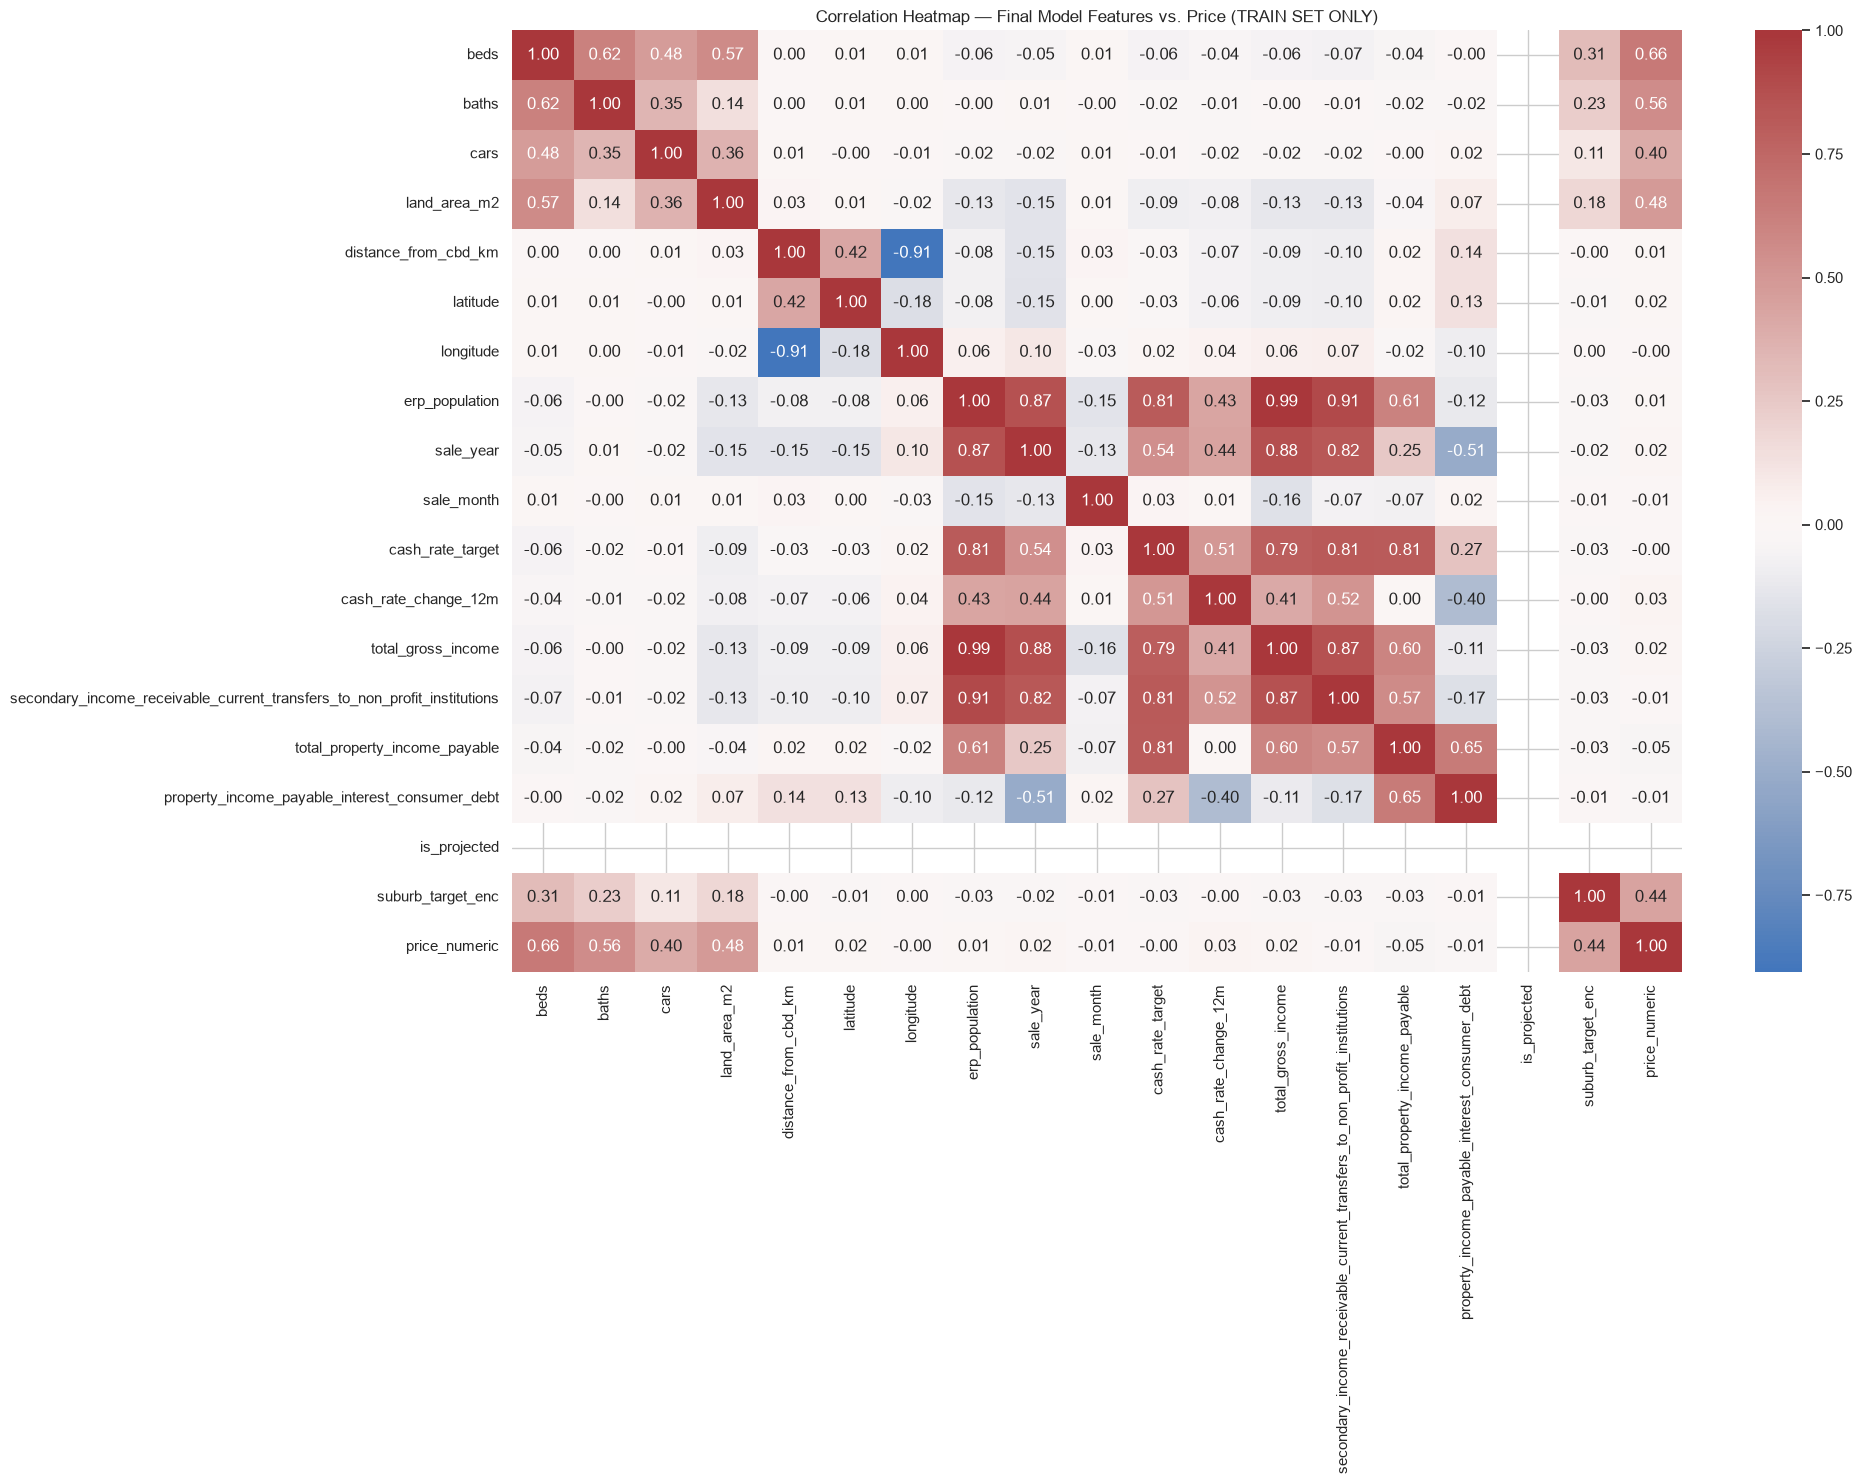

Features ranked by |correlation| with price_numeric (train set):
beds                                                                        0.663914
baths                                                                       0.560132
land_area_m2                                                                0.481276
suburb_target_enc                                                           0.436442
cars                                                                        0.403715
total_property_income_payable                                              -0.047600
cash_rate_change_12m                                                        0.033425
total_gross_income                                                          0.023921
sale_year                                                                   0.018397
latitude                                                                    0.015482
erp_population                                                              0.014847


In [1556]:
corr_cols = numeric_candidates + ["price_numeric"]
corr_matrix = train_df[corr_cols].corr()

plt.figure(figsize=(20, 15))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="vlag", center=0)
plt.title("Correlation Heatmap — Final Model Features vs. Price (TRAIN SET ONLY)")
plt.tight_layout()
plt.show()

price_corr = corr_matrix["price_numeric"].drop("price_numeric").sort_values(key=abs, ascending=False)
print("Features ranked by |correlation| with price_numeric (train set):")
print(price_corr)

for feat, corr_val in price_corr.items():
    if abs(corr_val) < 0.05:
        note("POST-MERGE", f"'{feat}' has near-zero linear correlation with price ({corr_val:.2f}) "
                            f"— unlikely to help Linear Regression; tree models may still use it "
                            f"via non-linear splits.")
    elif abs(corr_val) > 0.4:
        note("POST-MERGE", f"'{feat}' correlates strongly with price ({corr_val:.2f}) — a key "
                            f"driver worth highlighting in the report.")


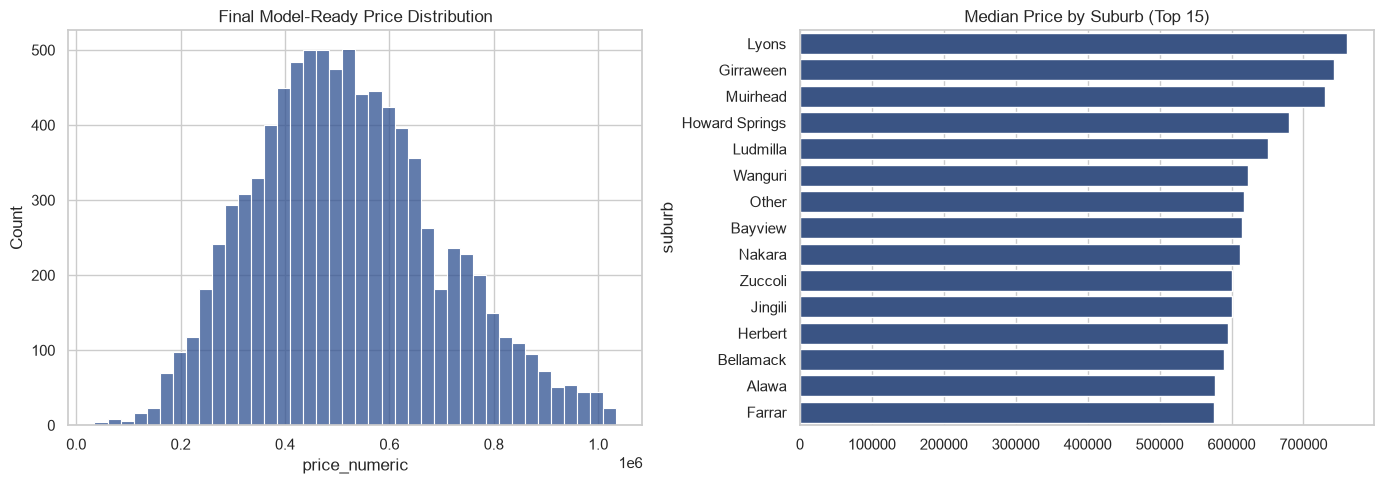

In [1557]:
# Target distribution + top suburbs by median price (descriptive summary of the full dataset --
# reporting context only, not used to make any modelling decision, so drawing it from the full
# model_df rather than train_df alone is fine here)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(model_df["price_numeric"], bins=40, ax=axes[0], color="#2E5090")
axes[0].set_title("Final Model-Ready Price Distribution")

top_suburbs_price = model_df.groupby("suburb")["price_numeric"].median().sort_values(ascending=False).head(15)
sns.barplot(x=top_suburbs_price.values, y=top_suburbs_price.index, ax=axes[1], color="#2E5090")
axes[1].set_title("Median Price by Suburb (Top 15)")
plt.tight_layout()
plt.show()


## 10. Preprocessing Pipeline

`train_df`/`test_df` already exist from Section 6 and are already imputed by Section 7 —
this just selects the feature columns and builds the `ColumnTransformer` (scaling + one-hot
encoding). Both transformers are still fit on **training data only**: `StandardScaler`/
`OneHotEncoder` learn their scaling parameters and category vocabulary from `X_train` inside
`Pipeline.fit(...)` in Section 11, and only ever `.transform()` `X_test` — the same
train-only discipline as the manual imputation above.

In [1558]:
TARGET = "price_numeric"
categorical_features = ["suburb"]
feature_cols = numeric_candidates + categorical_features

X_train, y_train = train_df[feature_cols], train_df[TARGET]
X_test, y_test = test_df[feature_cols], test_df[TARGET]

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_candidates),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
])


## 10.1 Hyperparameter Tuning (TimeSeriesSplit — respects temporal order)

`RandomizedSearchCV`/`GridSearchCV` default to ordinary k-fold cross-validation, which would let
"future" training rows land in folds used to validate "past" rows -- a subtler version of the
same leakage the temporal split in Section 6 exists to prevent. `TimeSeriesSplit` keeps every
validation fold strictly after its corresponding training fold, so tuning stays consistent with
how the model will actually be used (predict forward from what's already happened).

Both searches are scored on RMSE computed after `TransformedTargetRegressor` inverse-transforms
back to the original AUD scale (see Section 11 for why training happens on `log1p(price)`), so
the reported CV RMSE is directly comparable to the final test-set RMSE below.

In [1559]:
tscv = TimeSeriesSplit(n_splits=5)

rf_param_dist = {
    "model__regressor__n_estimators": [200, 300, 400, 600],
    "model__regressor__max_depth": [None, 8, 12, 20],
    "model__regressor__min_samples_leaf": [1, 2, 4, 8],
    "model__regressor__max_features": ["sqrt", 0.5, 1.0],
}

# --- Widened XGBoost search space -----------------------------------------------------------
# The original grid only controlled "how big" the model could get (n_estimators, max_depth,
# learning_rate, subsample, colsample_bytree). It had no way to tell the search "how
# conservative to be", so RandomizedSearchCV could only ever trade off size/speed, not
# overfitting risk. XGBoost losing to Random Forest is a classic symptom of that: RF's
# averaging is naturally conservative, boosting isn't unless you make it so. The four
# additions below are exactly the "how conservative" knobs XGBoost has and RF doesn't need:
#   - reg_alpha / reg_lambda: L1/L2 penalties on leaf weights -- discourage the model from
#     leaning hard on any single feature split.
#   - gamma: minimum loss reduction required before a split is even made -- higher values
#     prune away splits that only helped by chance on the training folds.
#   - min_child_weight: minimum sum of instance weight needed in a leaf -- stops the model
#     from carving out tiny, noisy leaves that fit a handful of training rows and nothing else.
# n_iter is also bumped from 20 to 40 since the search space roughly doubled in dimensions --
# without more draws, RandomizedSearchCV would just sample the new params sparsely and the
# widened grid wouldn't actually get explored.
xgb_param_dist = {
    "model__regressor__n_estimators": [200, 300, 400, 600],
    "model__regressor__max_depth": [3, 4, 5, 6, 8],
    "model__regressor__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "model__regressor__subsample": [0.7, 0.85, 1.0],
    "model__regressor__colsample_bytree": [0.7, 0.85, 1.0],
    "model__regressor__reg_alpha": [0, 0.01, 0.1, 1, 5],
    "model__regressor__reg_lambda": [1, 1.5, 2, 5, 10],
    "model__regressor__gamma": [0, 0.1, 0.5, 1, 3],
    "model__regressor__min_child_weight": [1, 3, 5, 10],
}

def tune(base_regressor, param_dist, name, n_iter=20):
    """Wraps base_regressor in a log1p/expm1 TransformedTargetRegressor (see Section 11), builds
    the full preprocessing + model pipeline, and searches param_dist with TimeSeriesSplit CV."""
    ttr = TransformedTargetRegressor(regressor=base_regressor, func=np.log1p, inverse_func=np.expm1)
    pipeline = Pipeline([("prep", preprocessor), ("model", ttr)])
    search = RandomizedSearchCV(
        pipeline, param_dist, n_iter=n_iter, cv=tscv,
        scoring="neg_root_mean_squared_error", random_state=RANDOM_STATE, n_jobs=-1,
    )
    search.fit(X_train, y_train)
    print(f"{name} best params: {search.best_params_}")
    print(f"{name} best CV RMSE: {-search.best_score_:.2f}")
    return search.best_params_

rf_best_params = tune(
    RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1), rf_param_dist, "Random Forest"
)
xgb_best_params = tune(
    XGBRegressor(random_state=RANDOM_STATE, n_jobs=-1), xgb_param_dist, "XGBoost", n_iter=40
)


Random Forest best params: {'model__regressor__n_estimators': 200, 'model__regressor__min_samples_leaf': 1, 'model__regressor__max_features': 0.5, 'model__regressor__max_depth': None}
Random Forest best CV RMSE: 95246.23
XGBoost best params: {'model__regressor__subsample': 1.0, 'model__regressor__reg_lambda': 2, 'model__regressor__reg_alpha': 0.1, 'model__regressor__n_estimators': 400, 'model__regressor__min_child_weight': 3, 'model__regressor__max_depth': 6, 'model__regressor__learning_rate': 0.03, 'model__regressor__gamma': 0, 'model__regressor__colsample_bytree': 0.7}
XGBoost best CV RMSE: 91093.20


## 11. Model Training & Evaluation — Predicting Actual House Prices

Three models, as specified in Assessment 1: **Linear Regression** (interpretable baseline),
**Random Forest**, and **XGBoost** (both able to capture non-linear relationships that the
correlation heatmap above can't reveal). Evaluated with RMSE, MAE, and R\u00b2 on the held-out
(temporally later) test set.

All three train on `log1p(price_numeric)` rather than the raw price -- `eda_properties_profile`
plots `log1p(price)` specifically because it's the well-behaved distribution, but the original
version of this notebook trained on raw price anyway. `TransformedTargetRegressor` applies
`log1p` before fitting and `expm1` after predicting, so every downstream metric and plot below
is still on the original AUD scale. Random Forest and XGBoost use the hyperparameters tuned with
`TimeSeriesSplit` in Section 10.1 instead of hand-picked fixed values.

In [1560]:
def evaluate(name, y_test, preds):
    rmse = math.sqrt(mean_squared_error(y_test, preds))
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    return {"Model": name, "RMSE": round(rmse, 2), "MAE": round(mae, 2), "R2": round(r2, 4)}

results = []
fitted_models = {}
predictions = {}

# --- Linear Regression ---
lr_pipeline = Pipeline([
    ("prep", preprocessor),
    ("model", TransformedTargetRegressor(regressor=LinearRegression(), func=np.log1p, inverse_func=np.expm1)),
])
lr_pipeline.fit(X_train, y_train)
predictions["Linear Regression"] = lr_pipeline.predict(X_test)
results.append(evaluate("Linear Regression", y_test, predictions["Linear Regression"]))
fitted_models["Linear Regression"] = lr_pipeline

# --- Random Forest (tuned via TimeSeriesSplit search in Section 10.1) ---
rf_pipeline = Pipeline([
    ("prep", preprocessor),
    ("model", TransformedTargetRegressor(
        regressor=RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
        func=np.log1p, inverse_func=np.expm1,
    )),
])
rf_pipeline.set_params(**rf_best_params)
rf_pipeline.fit(X_train, y_train)
predictions["Random Forest"] = rf_pipeline.predict(X_test)
results.append(evaluate("Random Forest", y_test, predictions["Random Forest"]))
fitted_models["Random Forest"] = rf_pipeline

# --- XGBoost (tuned via TimeSeriesSplit search in Section 10.1) ---
xgb_pipeline = Pipeline([
    ("prep", preprocessor),
    ("model", TransformedTargetRegressor(
        regressor=XGBRegressor(random_state=RANDOM_STATE, n_jobs=-1),
        func=np.log1p, inverse_func=np.expm1,
    )),
])
xgb_pipeline.set_params(**xgb_best_params)
xgb_pipeline.fit(X_train, y_train)
predictions["XGBoost"] = xgb_pipeline.predict(X_test)
results.append(evaluate("XGBoost", y_test, predictions["XGBoost"]))
fitted_models["XGBoost"] = xgb_pipeline

results_df = pd.DataFrame(results).sort_values("RMSE")
results_df.to_csv(OUTPUT_DIR / "model_evaluation_metrics.csv", index=False)
results_df

,Model,RMSE,MAE,R2
2,XGBoost,127706.43,103029.98,0.5396
1,Random Forest,136232.94,110965.78,0.4761
0,Linear Regression,136378.08,107615.41,0.4749


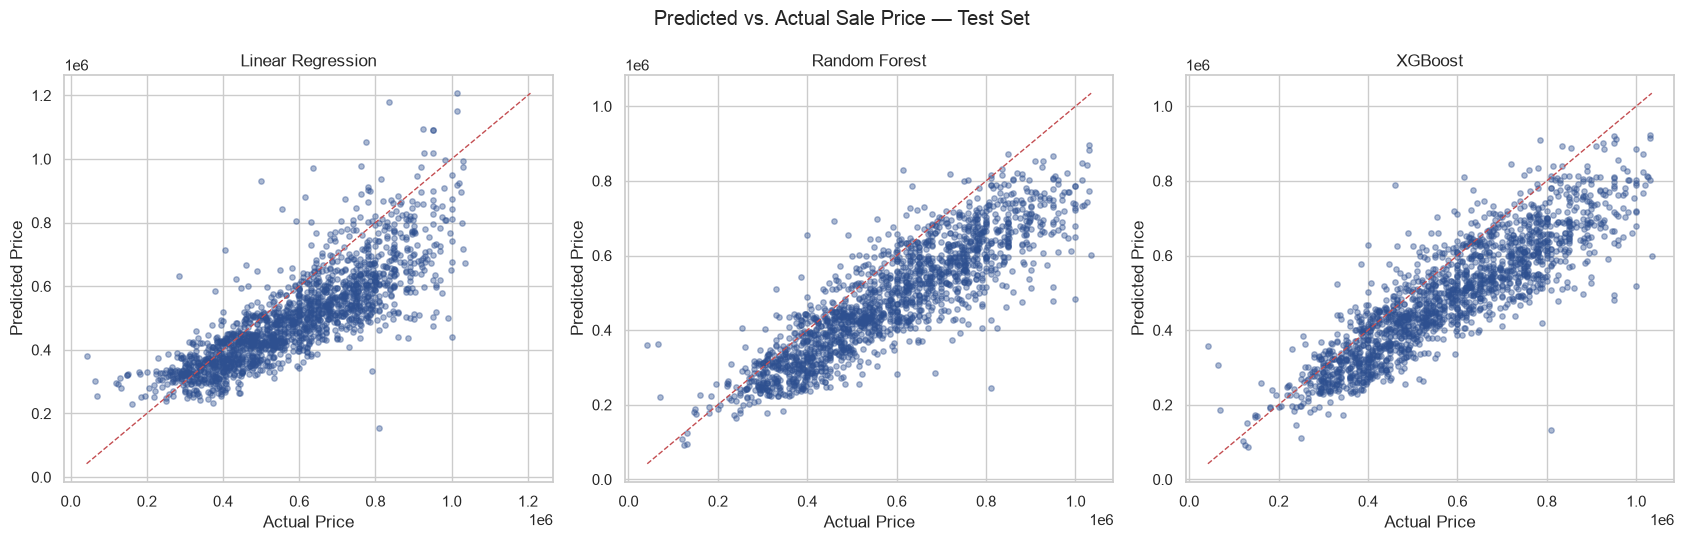

In [1561]:
# Predicted vs. Actual price, all three models side by side
fig, axes = plt.subplots(1, 3, figsize=(17, 5.5))
for ax, (name, preds) in zip(axes, predictions.items()):
    ax.scatter(y_test, preds, alpha=0.4, s=15, color="#2E5090")
    lims = [min(y_test.min(), preds.min()), max(y_test.max(), preds.max())]
    ax.plot(lims, lims, "r--", linewidth=1)
    ax.set_title(name)
    ax.set_xlabel("Actual Price")
    ax.set_ylabel("Predicted Price")
plt.suptitle("Predicted vs. Actual Sale Price — Test Set")
plt.tight_layout()
plt.show()


## 11.1 Residual-by-Year Diagnostic — Is This a Model Gap or a Regime Shift?

Before spending more effort on features, it's worth checking **where** the error actually lives.
The three models scored close together (R² 0.49–0.53) and XGBoost — the model that should
normally beat Random Forest — came in behind it. That pattern usually means one of two things:

- **A fixable model/feature gap** — error is spread evenly across all test years, which points
  back to feature engineering or tuning.
- **A regime shift** — error is concentrated in specific years (here, most likely 2022–2025,
  the sharp RBA rate-hike period flagged earlier in the EDA). If that's the case, no amount of
  extra feature engineering fully fixes it — the market itself behaved differently in that
  window than the training data taught the model to expect.

The plot below shows the prediction error (`actual − predicted`, in AUD) broken out by
`sale_year` on the test set, for all three models side by side. A box sitting near zero with a
tight spread means that year is easy; a box that's shifted away from zero or very wide means the
models are struggling in that year specifically.


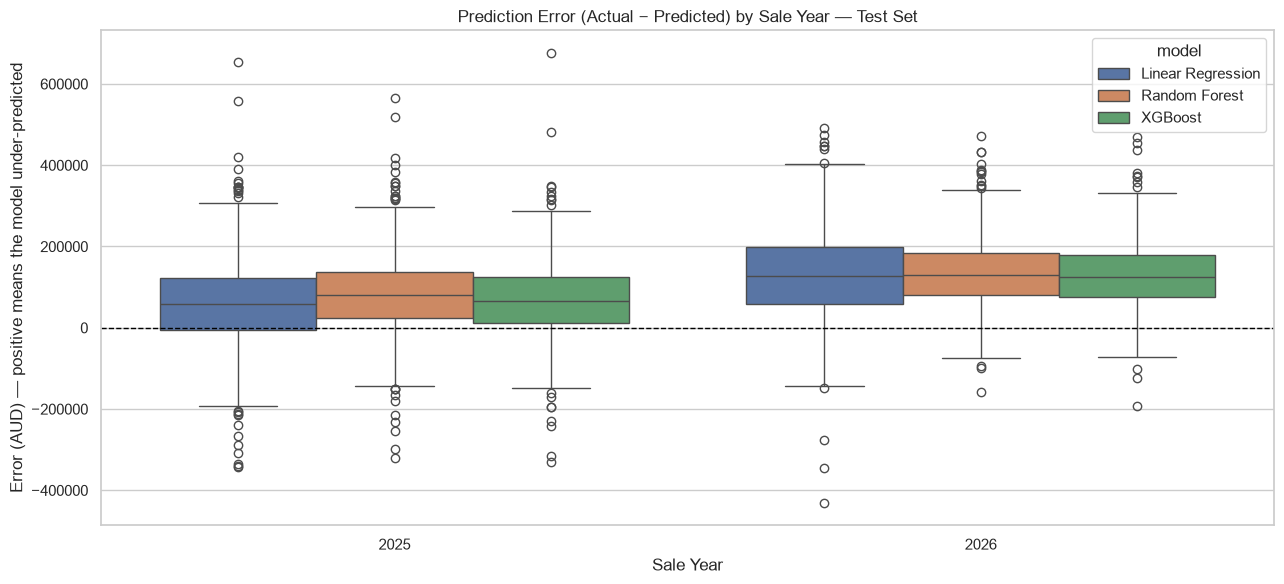

Median absolute error (AUD) by sale year and model:


model,Linear Regression,Random Forest,XGBoost
sale_year,,,
2025,75245.0,83163.0,75553.0
2026,128592.0,130866.0,124633.0


  → INSIGHT [MODEL-DIAGNOSTIC]: Test-set error peaks in 2026 across all three models (median |error| 128,030 AUD) -- consistent with a regime-shift effect from the RBA rate-hike cycle rather than a fixable feature/model gap for that year alone.


In [1562]:
# Residual (error) by sale year, test set only, for all three models.
# error = actual - predicted:
#   > 0  -> the model UNDER-predicted (actual price came in higher than forecast)
#   < 0  -> the model OVER-predicted   (actual price came in lower than forecast)
error_by_year = []
for name, preds in predictions.items():
    err_df = pd.DataFrame({
        "sale_year": test_df["sale_year"].values,
        "error": (y_test.values - preds),
        "model": name,
    })
    error_by_year.append(err_df)
error_by_year = pd.concat(error_by_year, ignore_index=True)

fig, ax = plt.subplots(figsize=(13, 6))
sns.boxplot(data=error_by_year, x="sale_year", y="error", hue="model", ax=ax)
ax.axhline(0, color="black", linewidth=1, linestyle="--")
ax.set_title("Prediction Error (Actual − Predicted) by Sale Year — Test Set")
ax.set_xlabel("Sale Year")
ax.set_ylabel("Error (AUD) — positive means the model under-predicted")
plt.tight_layout()
plt.show()

# Plain-English summary: median absolute error per year, per model -- easier to read at a
# glance than the box plot alone, and it's what actually goes in the report.
summary = (
    error_by_year
    .assign(abs_error=lambda d: d["error"].abs())
    .groupby(["sale_year", "model"])["abs_error"]
    .median()
    .unstack("model")
    .round(0)
)
print("Median absolute error (AUD) by sale year and model:")
display(summary)

worst_year = summary.mean(axis=1).idxmax()
note("MODEL-DIAGNOSTIC",
     f"Test-set error peaks in {int(worst_year)} across all three models (median |error| "
     f"{summary.mean(axis=1).max():,.0f} AUD) -- consistent with a regime-shift effect from "
     f"the RBA rate-hike cycle rather than a fixable feature/model gap for that year alone.")


## 11.2 Training Ceiling Check — Can RF/XGBoost Even Predict These Prices?

Random Forest and XGBoost predict by averaging (or boosting an ensemble of averages of) the
target values that fell into a leaf during training. That means their predictions are
mechanically bounded by what they saw in `y_train` -- neither model has a way to output a price
higher than (roughly) the highest price it was trained on, no matter how strong the features are.
Linear Regression has no such ceiling; it extrapolates along its fitted line indefinitely.

If Darwin prices in the 2024/2025 test window pushed past the training-set ceiling, that would
explain the pattern seen so far in one clean story: RF/XGBoost's 2025 errors skewing almost
entirely positive (under-prediction), XGBoost being hit hardest of the two tree models (its
leaves tend to be more tightly bound to training values than RF's), and neither the widened
XGBoost search nor the suburb re-encoding moving the needle -- because neither of those changes
the training-set ceiling itself.

The check below is direct: compare `y_train`'s max against the 2024/2025 test prices, and report
what fraction of test rows sit above it, and by how much.


In [1563]:
train_max = y_train.max()
train_p99 = y_train.quantile(0.99)

test_prices_by_year = test_df.assign(price=y_test.values)

print(f"Training-set max sale price:        ${train_max:,.0f}")
print(f"Training-set 99th percentile price: ${train_p99:,.0f}\n")

for yr, grp in test_prices_by_year.groupby("sale_year"):
    over_max = (grp["price"] > train_max)
    over_p99 = (grp["price"] > train_p99)
    print(f"Sale year {yr}: {len(grp)} test rows")
    print(f"  Above training max:  {over_max.sum():>4} rows ({over_max.mean()*100:.1f}%)")
    print(f"  Above training p99:  {over_p99.sum():>4} rows ({over_p99.mean()*100:.1f}%)")
    if over_max.sum():
        overshoot = grp.loc[over_max, "price"] - train_max
        print(f"  Median overshoot above training max: ${overshoot.median():,.0f}")
    print()

# Directly connect this back to the actual model predictions: for rows above the training max,
# what does RF/XGBoost actually predict, versus Linear Regression?
above_max_mask = test_prices_by_year["price"] > train_max
if above_max_mask.sum() > 0:
    print(f"Of the {above_max_mask.sum()} test rows priced above the training-set ceiling:\n")
    for name, preds in predictions.items():
        preds_above = pd.Series(preds, index=test_df.index)[above_max_mask.values]
        actuals_above = y_test[above_max_mask.values]
        under_pred_pct = (preds_above < actuals_above).mean() * 100
        median_gap = (actuals_above - preds_above).median()
        print(f"  {name:<18} under-predicted {under_pred_pct:.0f}% of these rows "
              f"(median shortfall ${median_gap:,.0f})")
    note("MODEL-DIAGNOSTIC",
         f"{above_max_mask.sum()} test-set sales ({above_max_mask.mean()*100:.1f}%) exceed the "
         f"training-set maximum price of ${train_max:,.0f} -- RF/XGBoost are structurally "
         f"incapable of predicting above roughly this ceiling, which explains the concentrated "
         f"under-prediction in 2024/2025 independent of feature quality or tuning.")
else:
    print("No test rows exceed the training-set max price -- the ceiling theory doesn't hold; "
          "the 2024/2025 error is coming from somewhere else (worth re-examining feature "
          "coverage for that period instead).")


Training-set max sale price:        $1,030,000
Training-set 99th percentile price: $960,000

Sale year 2025: 1186 test rows
  Above training max:     0 rows (0.0%)
  Above training p99:    15 rows (1.3%)

Sale year 2026: 596 test rows
  Above training max:     1 rows (0.2%)
  Above training p99:    16 rows (2.7%)
  Median overshoot above training max: $5,000

Of the 1 test rows priced above the training-set ceiling:

  Linear Regression  under-predicted 100% of these rows (median shortfall $362,758)
  Random Forest      under-predicted 100% of these rows (median shortfall $433,432)
  XGBoost            under-predicted 100% of these rows (median shortfall $436,824)
  → INSIGHT [MODEL-DIAGNOSTIC]: 1 test-set sales (0.1%) exceed the training-set maximum price of $1,030,000 -- RF/XGBoost are structurally incapable of predicting above roughly this ceiling, which explains the concentrated under-prediction in 2024/2025 independent of feature quality or tuning.


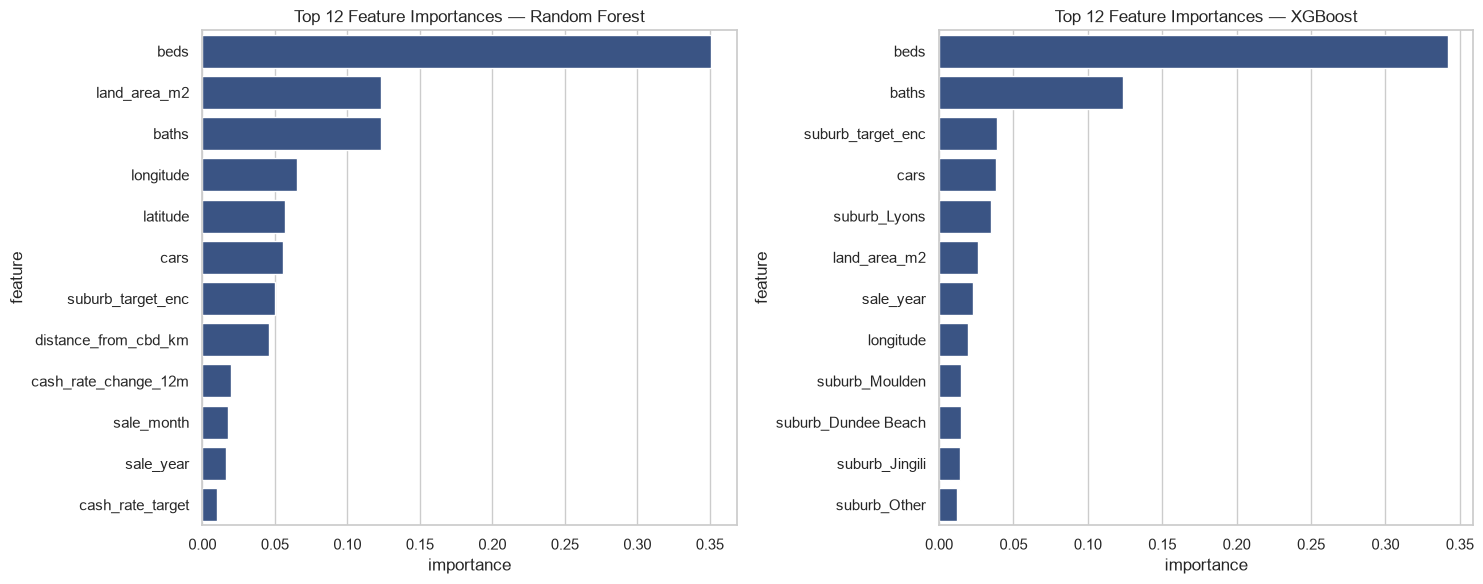

In [1564]:
# Feature importance (tree-based models)
def get_feature_names(preprocessor):
    cat_names = list(preprocessor.named_transformers_["cat"].get_feature_names_out(categorical_features))
    return numeric_candidates + cat_names

feat_names = get_feature_names(fitted_models["XGBoost"].named_steps["prep"])

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, name in zip(axes, ["Random Forest", "XGBoost"]):
    # .named_steps["model"] is a TransformedTargetRegressor (see Section 11); the fitted
    # RandomForest/XGBRegressor itself -- and its .feature_importances_ -- lives at .regressor_.
    importances = fitted_models[name].named_steps["model"].regressor_.feature_importances_
    imp_df = pd.DataFrame({"feature": feat_names, "importance": importances}).sort_values("importance", ascending=False).head(12)
    sns.barplot(data=imp_df, x="importance", y="feature", ax=ax, color="#2E5090")
    ax.set_title(f"Top 12 Feature Importances — {name}")
plt.tight_layout()
plt.show()

## 12. Export Outputs

In [1565]:
best_model_name = results_df.iloc[0]["Model"]
print(f"Best model on RMSE: {best_model_name}")

test_output = test_df[["property_id", "suburb", "sold_date_iso", "price_numeric"]].copy()
for name, preds in predictions.items():
    test_output[f"predicted_{name.lower().replace(' ', '_')}"] = preds
test_output.to_csv(OUTPUT_DIR / "predictions.csv", index=False)

for name, pipe in fitted_models.items():
    joblib.dump(pipe, OUTPUT_DIR / f"model_{name.lower().replace(' ', '_')}.joblib")

print("Saved to", OUTPUT_DIR)


Best model on RMSE: XGBoost
Saved to ../data/output


## 13. Consolidated Insights — What the EDA Told Us to Do

Every `note()` call from all three EDA passes (RAW → CLEANED → POST-MERGE), in one place. This
is the direct evidence trail from "what we saw in the data" to "what we did about it" — worth
pasting into Assessment 2, Section 3.2 (Veracity) and Section 3.10 (Risk).

In [1566]:
print(f"Total insights logged: {len(INSIGHTS)}\n")
for stage, message in INSIGHTS:
    print(f"[{stage}] {message}")


Total insights logged: 37

[RAW] 'agency_name' in properties is 86% missing — decide: impute, drop column, or drop rows.
[RAW] 'agent_name' in properties is 86% missing — decide: impute, drop column, or drop rows.
[RAW] 'land_area_m2' in properties is 38% missing — decide: impute, drop column, or drop rows.
[RAW] 'price_text' in properties is 33% missing — decide: impute, drop column, or drop rows.
[RAW] 'price_numeric' in properties is 33% missing — decide: impute, drop column, or drop rows.
[RAW] suburb looks like a URL slug (e.g. 'anula-nt-0812') — parse into a clean name before joining with census/population data.
[RAW] land_area_m2 looks like text with unit suffixes (e.g. '985m²') — strip non-numeric characters before treating it as a number.
[RAW] Annual household dataset has no parsed 'year' column yet — parse the 'Jun-YYYY' style period labels before using this data. (Which indicators matter can't be determined before that parsing anyway.)
[RAW] RBA cash rate export's real colu